# **Exploring Genomics of Drug Sensitivity in Cancer (GDSC)**


**Author:** Sylvia  Obiageli Onwuanabile  
**Date:** June 15, 2026  
**Institution:** HackBio Internship



# Project Overview

Cancer drug response varies considerably across cancer types due to differences in their molecular, genomic, and biological characteristics. Understanding these differences is critical for identifying effective therapies and advancing precision medicine.

This project explores the Genomics of Drug Sensitivity in Cancer (GDSC) dataset, a large-scale pharmacogenomics resource containing drug response measurements across diverse cancer cell lines. Using exploratory data analysis, statistical testing, and data visualization, the study investigates patterns of drug sensitivity and resistance across drugs, cancer types, molecular features, and biological pathways.

The analysis focuses on identifying highly effective and ineffective drugs, evaluating cancer-type-specific responses, assessing the influence of genomic, transcriptomic, and epigenomic factors, and examining pathway-level patterns associated with treatment response. The findings provide insights into the biological determinants of drug sensitivity and demonstrate how data-driven approaches can support precision oncology and therapeutic decision-making.


# Objectives

The objectives of this study are to:
 
- Explore the distribution of drug sensitivity metrics (LN_IC50, AUC, and Z_SCORE).
- Identify the most sensitive and resistant drugs.
- Determine whether specific cancer types respond better to particular drugs.
- Investigate drug selectivity across cancer types.
- Assess the influence of genomic, transcriptomic, and epigenomic features on drug response.
- Examine the effects of microsatellite instability and growth characteristics.
- Identify biological pathways associated with drug sensitivity.
- Communicate findings through clear visualizations and statistical analyses.

# 1. Introduction

Cancer remains one of the leading causes of morbidity and mortality worldwide. Despite significant advances in cancer treatment, responses to therapeutic agents vary considerably across cancer types and individual tumors due to differences in their molecular and biological characteristics. Understanding the factors that influence drug sensitivity is therefore essential for improving treatment selection and advancing precision medicine.

The Genomics of Drug Sensitivity in Cancer (GDSC) project provides a large-scale pharmacogenomic resource that links drug response data with molecular features across a diverse collection of cancer cell lines (Yang et al., 2013). The dataset includes measurements of drug sensitivity, such as LN_IC50, Area Under the Curve (AUC), and Z-scores, alongside information on cancer type, microsatellite instability status, growth properties, copy number alterations (CNA), gene expression, methylation status, and drug target pathways.

In this study, patterns of drug sensitivity across cancer cell lines were investigated to evaluate the influence of genomic, transcriptomic, epigenomic, and biological factors on treatment response. Specifically, this study examined the most and least effective drugs, differences in sensitivity across cancer types, the impact of molecular features on drug response, and pathway-level patterns of drug activity. Through statistical analysis and data visualization, this project provides insights into the biological determinants of drug sensitivity and highlights the importance of personalized approaches to cancer treatment (Iorio et al., 2016).


# 2. Dataset Overview


The Genomics of Drug Sensitivity in Cancer (GDSC) dataset contains large-scale pharmacogenomic data linking drug response measurements with molecular characteristics of cancer cell lines.

### Dataset Summary

| Feature                | Value                                   |
| ---------------------- | --------------------------------------- |
| Number of observations | 162,103                                 |
| Number of variables    | 19                                      |
| Drug response metrics  | LN_IC50, AUC, Z_SCORE                   |
| Molecular features     | CNA, Gene Expression, Methylation       |
| Biological features    | MSI Status, Growth Properties           |
| Drug information       | Drug Name, Target, Target Pathway       |
| Cancer information     | TCGA Cancer Type and Tissue Descriptors |

LN_IC50 = natural logarithm of IC50 (half‑maximal inhibitory concentration).

AUC = area under the dose–response curve.

Z‑Score = normalized sensitivity measure relative to the dataset mean.

The dataset was examined for structure, completeness, and consistency before downstream analysis.


## 2.1 Setup and Data Ingestion

In [61]:
# Import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
sns.set_theme(style='whitegrid')

In [62]:
# Load dataset

gdsc = pd.read_excel('https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx')


The dataset was obtained from the HackBio Internship public datasets repository and is derived from the GDSC resource.

The GDSC dataset was imported into Python using pandas and inspected to understand its structure, variables, and data types.

In [63]:
# Inspect dataset

print('Shape:', gdsc.shape)
gdsc.info()
gdsc.head()

Shape: (162103, 19)
<class 'pandas.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  str    
 2   TCGA_DESC                                162103 non-null  str    
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  str    
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  str    
 9   GDSC Tissue descriptor 2                 162103 non-null  str    
 10  Cancer Type (matching T

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


The dataset contains 162,103 observations and 19 variables, including drug sensitivity measurements (LN_IC50, AUC, Z_SCORE), cancer type annotations, molecular features, and drug target information. No missing values were observed across the dataset, indicating a complete dataset suitable for downstream analysis.

## 2.2 Data Quality and Validity Checks

In [64]:
# descriptive statistics summary

gdsc.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.621030e+05,162103.000000,162103.000000,162103.000000,162103.000000
mean,9.857634e+05,1554.527603,2.822644,0.879924,0.037711
std,2.240213e+05,406.964712,2.836231,0.148592,0.999098
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716
25%,9.059780e+05,1086.000000,1.476170,0.845967,-0.615884
50%,9.092570e+05,1598.000000,3.271447,0.941467,0.048930
75%,1.240143e+06,1910.000000,4.767629,0.973917,0.686466
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776


In [65]:
# Range and validity checks

print("LN_IC50 range:", gdsc['LN_IC50'].min(), "to", gdsc['LN_IC50'].max())
print("Median LN_IC50:", gdsc['LN_IC50'].median())

print("AUC range:", gdsc['AUC'].min(), "to", gdsc['AUC'].max())
print("Median AUC:", gdsc['AUC'].median())

print("All AUC values valid:", gdsc['AUC'].between(0,1).all())

LN_IC50 range: -8.642551 to 13.820189
Median LN_IC50: 3.271447
AUC range: 0.006282 to 0.998904
Median AUC: 0.941467
All AUC values valid: True


### Interpretation

To ensure the dataset was clean and biologically meaningful, the ranges and validity of the key drug sensitivity measures were examined:

- **LN_IC50** values ranged from −8.64 to +13.82, with a median of 3.27.  
  This wide span reflects the diversity of drug potencies across cell lines, from extremely potent compounds (negative LN_IC50 values) to highly resistant responses (positive LN_IC50 values). The high median indicates that most drugs did not fully suppress cell growth at tested concentrations.

- **AUC** values ranged from 0.006 to 0.999, with a median of 0.94.  
  All AUC values fell within the expected range of [0,1], confirming validity.

Overall, the wide LN_IC50 range highlights substantial variation in drug sensitivity across cancer cell lines, while the valid AUC range confirms the dataset is suitable for downstream analysis.



## 2.3 Global Distributions of Drug Sensitivity Measures

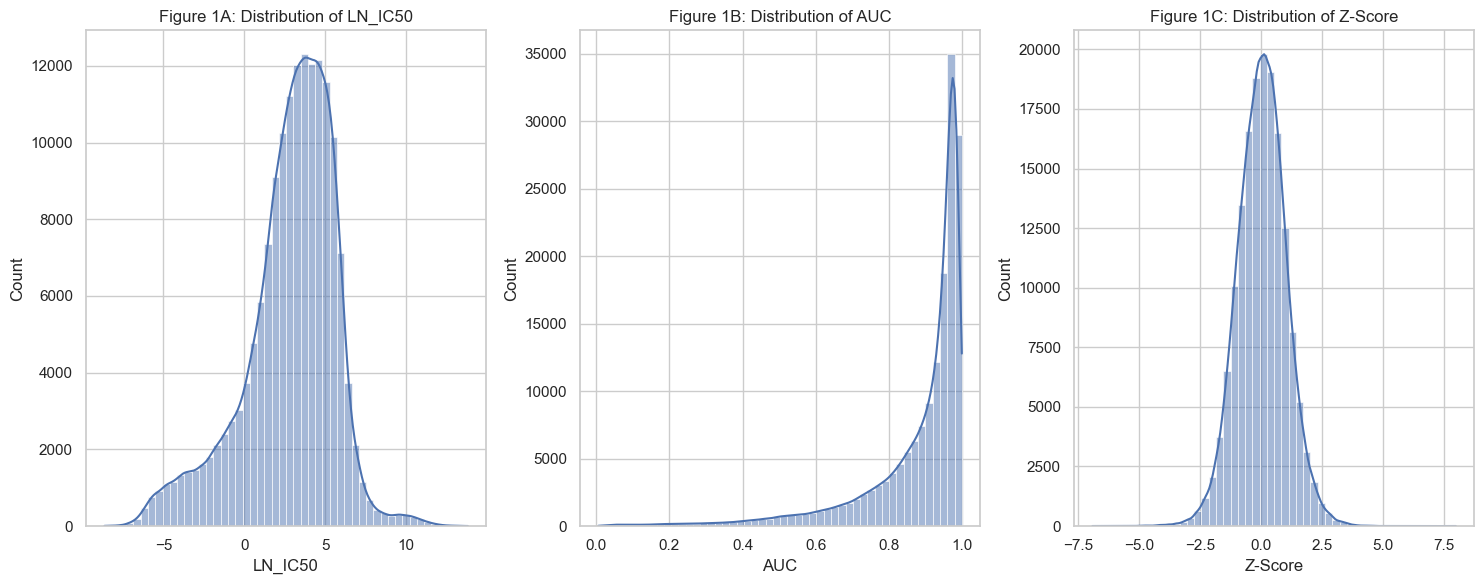

In [86]:
# Global distributions Histoplots

plt.figure(figsize=(15,6))

plt.subplot(1,3,1)
sns.histplot(gdsc['LN_IC50'], bins=50, kde=True)
plt.title('Figure 1A: Distribution of LN_IC50')
plt.xlabel('LN_IC50')
plt.ylabel('Count')

plt.subplot(1,3,2)
sns.histplot(gdsc['AUC'], bins=50, kde=True)
plt.title('Figure 1B: Distribution of AUC')
plt.xlabel('AUC')
plt.ylabel('Count')

plt.subplot(1,3,3)
sns.histplot(gdsc['Z_SCORE'], bins=50, kde=True)
plt.title('Figure 1C: Distribution of Z-Score')
plt.xlabel('Z-Score')
plt.ylabel('Count')

plt.tight_layout()

# Save first, then show
plt.savefig("figures/Figure1_Global_Distributions.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 1. Global distributions of drug sensitivity measures.** 

Histograms showing the distribution of LN_IC50 (A), AUC (B), and Z-Score (C) across all drug–cancer combinations. X‑axes represent each metric, Y‑axes show count. LN_IC50 values are centered around moderate sensitivity levels, AUC values are concentrated near 1.0, and Z-Scores are approximately centered around zero, reflecting standardized drug response measurements.

### Interpretation

As shown in Figure 1A–C, the global distributions of LN_IC50, AUC, and Z_SCORE were examined to characterize overall drug response patterns across the dataset.

#### LN_IC50 Distribution
Values ranged from −8.64 to +13.82 and were approximately normally distributed, centered around 3–4.  
This indicates that most drugs require moderate concentrations to inhibit 50% of cell growth.  
A small tail toward higher values reflects resistant responses, while negative values highlight exceptionally potent drugs.

#### AUC Distribution
Values ranged from 0.006 to 0.999 and were heavily right‑skewed, with most clustered near 1.0.  
This suggests that many drugs do not fully suppress cancer cell growth at tested concentrations.  
The median AUC of 0.94 confirms that partial inhibition is the dominant pattern.  
Validity check: All AUC values valid = True, confirming no out‑of‑range or corrupted entries.

#### Z‑Score Distribution
Values were symmetric and centered around 0, as expected by construction.  
This normalization ensures comparability across drugs and cell lines, with negative scores indicating stronger‑than‑average sensitivity and positive scores indicating weaker‑than‑average sensitivity.

---

**Summary:**  
- LN_IC50 highlights the potency spectrum of drugs, ranging from highly effective to resistant.  
- AUC emphasizes overall efficacy, showing that most drugs achieve only partial inhibition.  
- Z‑Score provides a relative sensitivity measure, useful for comparing across the dataset.  

Together, **Figure 1** confirms that the dataset is clean, valid, and biologically coherent, while also revealing the heterogeneity of drug responses across cancer cell lines.


# 3. Dataset Exploration

Research Questions
1. What are the key variables in the dataset?
2. What does each column represent (see metadata description)?
3. Are there missing values or inconsistencies?

## 3.1 The key Variables in the Dataset:

- COSMIC_ID → unique cell line identifier

- CELL_LINE_NAME → name of cell line

- TCGA_DESC / Cancer Type → cancer type classification

- DRUG_NAME / DRUG_ID → drug tested

- LN_IC50, AUC, Z_SCORE → drug sensitivity measures / drug response matrix

- Genomic features → CNA, Gene Expression, Methylation

- TARGET / TARGET_PATHWAY → drug target biology

## 3.2 What Each Column Represent

## Metadata   Description

| Column                               | Description                                                                 |
|--------------------------------------|-----------------------------------------------------------------------------|
| COSMIC_ID                            | Unique Identifier on COSMIC                                                 |
| CELL_LINE_NAME                       | Name of cell line                                                           |
| TCGA_DESC                            | TCGA Code for cancer type ([TCGA Study Abbreviations](https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tcga-study-abbreviations)) |
| DRUG_ID                              | Drug ID                                                                     |
| DRUG_NAME                            | Drug Name                                                                   |
| LN_IC50                              | Natural logarithm of the IC50                                               |
| AUC                                  | Area under the dose dependent curve                                         |
| Z_SCORE                              | Z score of deviations from the mean of zero; the closer to zero, the better |
| GDSC Tissue descriptor 1             | System description                                                          |
| GDSC Tissue descriptor 2             | Specific organ or tissue                                                    |
| Cancer Type (matching TCGA label)    | Same as the TCGA                                                            |
| Microsatellite instability Status (MSI) | MSI-L (Minor instability), MSI-H (High instability), MSS (No instability or repaired mutation) |
| Screen Medium                        | Medium for screening                                                        |
| Growth Properties                    | Growth properties                                                           |
| CNA                                  | Is copy number altered?                                                     |
| Gene Expression                      | Is gene expressed?                                                          |
| Methylation                          | Is gene methylated?                                                         |
| TARGET                               | Genetic target of drug                                                      |
| TARGET_PATHWAY                       | Pathway of genetic target                                                   |


Each column represents either a cell line identifier, a drug property, a sensitivity measure, or a molecular feature. Together, they form the drug–cell line response matrix.

## 3.3 Missing Values and Data Consistency

In [67]:
# Check if missing value exist
gdsc.isnull().any().any()

np.False_

In [68]:
# Check if duplicates exist
gdsc.duplicated().any().any()

np.False_

### Interpretation

No missing or duplicate values were detected across the dataset. All variables were complete and no major inconsistencies were identified, allowing subsequent analyses to be performed without imputation or extensive preprocessing.

# 4. Drug Sensitivity Patterns

Drug effectiveness was assessed using median LN_IC50 and median AUC across all cancer cell lines.

Lower LN_IC50 → higher sensitivity (drug works at low dose).

Lower AUC → stronger overall inhibition.

Variability → measured by standard deviation (some cancers sensitive, others resistant).

Z‑Score → validation measure (negative = above‑average sensitivity, positive = below‑average).

Research Questions

      1. Which drugs appear to be the most effective
      2. Which drug show the least effectiveness
      3. Are there drugs with highly variable responses across cell lines

## 4.1 Most Effective Drugs

In [69]:
# a.  Most effective drugs (lowest median LN_IC50)

most_effective_LN_IC50 = gdsc.groupby('DRUG_NAME')['LN_IC50'].median().sort_values().head(40)
print(most_effective_LN_IC50)

DRUG_NAME
Romidepsin                -5.317812
Bortezomib                -4.906318
Sepantronium bromide      -4.210507
Docetaxel                 -3.990660
Daporinad                 -3.902214
Dactinomycin              -3.820755
Vinblastine               -3.783500
SN-38                     -3.510652
Paclitaxel                -3.194081
Eg5_9814                  -3.137055
Vinorelbine               -3.117927
Dinaciclib                -2.983147
Staurosporine             -2.667322
Luminespib                -2.402346
Camptothecin              -2.391764
CDK9_5038                 -2.349072
Elesclomol                -1.893472
Rapamycin                 -1.873709
Dactolisib                -1.577113
MG-132                    -1.359344
BI-2536                   -1.082866
Gemcitabine               -0.964458
Epirubicin                -0.819802
CDK9_5576                 -0.481237
LMP744                    -0.417370
Sabutoclax                -0.240843
Tanespimycin              -0.168561
AZD8055           

In [70]:
# b.  Most effective drugs (lowest median AUC)

most_effective_AUC = gdsc.groupby('DRUG_NAME')['AUC'].median().sort_values().head(40)
print(most_effective_AUC)

DRUG_NAME
Sepantronium bromide       0.174748
Staurosporine              0.420281
CDK9_5038                  0.500769
MG-132                     0.519507
Dinaciclib                 0.557455
CDK9_5576                  0.584322
Dactinomycin               0.587657
Sabutoclax                 0.607323
Daporinad                  0.650521
Gemcitabine                0.681688
Obatoclax Mesylate         0.691580
MK-1775                    0.695333
Telomerase Inhibitor IX    0.696328
Luminespib                 0.706495
GNE-317                    0.706881
AZD7762                    0.707720
LMP744                     0.715728
Pevonedistat               0.719760
Vinblastine                0.728767
Foretinib                  0.744547
Epirubicin                 0.746470
Buparlisib                 0.751484
VSP34_8731                 0.764612
ULK1_4989                  0.769892
Bortezomib                 0.772874
BI-2536                    0.775329
PAK_5339                   0.778226
Topotecan         

### Interpretation

Drug effectiveness was assessed using both median LN_IC50 and median AUC values across all cancer cell lines. Lower LN_IC50 values indicate greater drug potency, while lower AUC values indicate stronger overall inhibition of cancer cell growth.

Based on median LN_IC50, the most potent drugs were Romidepsin, Bortezomib, Sepantronium bromide, Docetaxel, and Daporinad. Romidepsin exhibited the lowest median LN_IC50 value (-5.32), suggesting exceptional potency across the tested cell lines.

Using median AUC as a complementary measure, Sepantronium bromide, Staurosporine, CDK9_5038, MG-132, and Dinaciclib demonstrated the strongest overall growth inhibition. 

The consistency between LN_IC50 and AUC rankings strengthens confidence that these compounds exhibit broad and potent anticancer activity across multiple cancer cell lines.

## 4.2 Least Effective Drugs

In [71]:
# a. Least effective drugs (Highest median LN_IC50)

least_effective_LN_IC50 = gdsc.groupby('DRUG_NAME')['LN_IC50'].median().sort_values(ascending=False).head(50)
print(least_effective_LN_IC50)

DRUG_NAME
ascorbate (vitamin C)    10.449790
N-acetyl cysteine         9.944135
glutathione               9.145341
alpha-lipoic acid         7.705239
Temozolomide              6.507988
Motesanib                 5.640039
EPZ5676                   5.622295
Dacarbazine               5.589772
GSK2830371                5.587867
LMB_AB1                   5.490826
PFI3                      5.464875
MIRA-1                    5.404574
Lenalidomide              5.379646
GSK3337463A               5.377516
AZD1208                   5.377112
Fludarabine               5.347530
GSK2830371A               5.320756
Picolinici-acid           5.317643
Veliparib                 5.310615
IAP_5620                  5.296113
Cyclophosphamide          5.287857
SB216763                  5.249631
THR-101                   5.229106
EPZ004777                 5.222632
CZC24832                  5.218146
CCT007093                 5.177400
JNK Inhibitor VIII        5.173108
KU-55933                  5.155369
LMB_AB3   

In [72]:
# b. Least sensitive drugs (Highest median AUC)

least_effective_AUC = gdsc.groupby('DRUG_NAME')['AUC'].median().sort_values(ascending=False).head(50)
print(least_effective_AUC)

DRUG_NAME
Motesanib                0.983200
GSK626616AC              0.983054
EPZ5676                  0.982808
IOX2                     0.982628
GSK2256098C              0.982515
PFI3                     0.981920
GSK2830371               0.981164
GSK2830371A              0.981030
LMB_AB1                  0.980587
MIRA-1                   0.980487
Picolinici-acid          0.979970
SB590885                 0.979482
Temozolomide             0.979478
AZD1208                  0.979343
GSK3337463A              0.979289
LY2109761                0.979081
Lenalidomide             0.979020
Ribociclib               0.979004
Cyclophosphamide         0.978992
SB216763                 0.978919
Veliparib                0.978823
CCT007093                0.978588
IWP-2                    0.978114
IAP_5620                 0.978099
CZC24832                 0.978017
EPZ004777                0.977693
SGC0946                  0.977496
JNK Inhibitor VIII       0.977322
BDILV000379a             0.977296
Savo

### Interpretation

Drug resistance was evaluated using median LN_IC50 and median AUC values. Higher LN_IC50 values indicate that larger drug concentrations are required to inhibit growth, while higher AUC values indicate weaker overall treatment responses.

Based on median LN_IC50, Ascorbate (Vitamin C), N-acetyl cysteine, Glutathione, Alpha-lipoic acid, and Temozolomide were among the least potent compounds. Ascorbate recorded the highest median LN_IC50 value (10.45), indicating very low activity across the dataset.

Similarly, Motesanib, EPZ5676, PFI3, GSK2830371, and Temozolomide exhibited some of the highest median AUC values.

These findings highlight compounds that showed limited effectiveness across the tested cancer cell lines.

## 4.3 Highly Variable Drugs Responses Across Cell Lines

In [73]:
# a. Standard deviation of LN_IC50 per drug (variability)

drug_variability_LNIC50 = gdsc.groupby('DRUG_NAME')['LN_IC50'].std().sort_values(ascending=False).head(40)
drug_variability_LNIC50

DRUG_NAME
Gemcitabine          2.941950
AZD5991              2.759418
Daporinad            2.735583
Docetaxel            2.546911
BI-2536              2.459347
Dasatinib            2.394058
Methotrexate         2.389344
Tozasertib           2.386865
AZD5582              2.345364
Trametinib           2.301612
LMP744               2.279247
Alisertib            2.267331
Cytarabine           2.230056
Vinblastine          2.199149
Mitoxantrone         2.183966
PD0325901            2.173146
Pevonedistat         2.135509
Vinorelbine          2.094116
Talazoparib          2.083172
Bleomycin (50 uM)    2.075884
ABT737               2.069307
Navitoclax           2.030280
BMS-754807           1.988400
Elesclomol           1.979979
JQ1                  1.972361
IGF1R_3801           1.946101
CDK9_5038            1.940858
AZD5153              1.940257
Fludarabine          1.939578
SN-38                1.933588
Venetoclax           1.915720
Refametinib          1.913018
Dabrafenib           1.909821


In [74]:
# b. Standard deviation of AUC per drug (variability)

drug_variability_AUC = gdsc.groupby('DRUG_NAME')['AUC'].std().sort_values(ascending=False).head(40)
drug_variability_AUC

DRUG_NAME
Dactinomycin            0.315533
SN-38                   0.263135
Docetaxel               0.258092
Gemcitabine             0.234819
Daporinad               0.223516
CDK9_5038               0.201548
BI-2536                 0.198379
Trametinib              0.194131
LMP744                  0.191312
Alisertib               0.187232
ABT737                  0.187068
AZD5991                 0.186487
AZD5582                 0.186384
Tozasertib              0.185867
Pevonedistat            0.182212
Mitoxantrone            0.178046
AZD5153                 0.174687
Dasatinib               0.172630
Methotrexate            0.172257
Vinblastine             0.170638
Staurosporine           0.170157
Refametinib             0.165173
Epirubicin              0.163793
AZD7762                 0.160917
Topotecan               0.156644
IGF1R_3801              0.156063
Sepantronium bromide    0.155433
Talazoparib             0.154817
JQ1                     0.154419
Bleomycin (50 uM)       0.154186


### Interpretation

To identify drugs with highly variable responses across cancer cell lines, the standard deviation of LN_IC50 and AUC values was calculated. Higher standard deviations indicate greater differences in response between cancer types.

Using LN_IC50 variability, Gemcitabine, AZD5991, Daporinad, Docetaxel, and BI-2536 exhibited the greatest variation. Similarly, AUC analysis identified Dactinomycin, SN-38, Docetaxel, Gemcitabine, and Daporinad as highly variable compounds.

Several drugs, including Gemcitabine, Daporinad, and Docetaxel, appeared among the most variable drugs in both analyses, indicating substantial differences in effectiveness across cancer types.

These findings suggest that drug response is highly context-dependent and may vary according to the biological characteristics of individual cancers.


## 4.4 Validation using Z-Scores

In [75]:
# Mean Z_SCORE per drug
median_zscore = gdsc.groupby('DRUG_NAME')['Z_SCORE'].median().sort_values()

print(median_zscore.head(20))   # most sensitive drugs (negative Median Z-Score)

print(median_zscore.tail(20))   # most resistant drugs (positive Median Z-Score)

# Variability of Z-SCORE (spread across cell lines)
std_zscore = gdsc.groupby('DRUG_NAME')['Z_SCORE'].std().sort_values(ascending=False).head(20)
print(std_zscore)


DRUG_NAME
Piperlongumine            -0.236211
Dinaciclib                -0.225151
CCT-018159                -0.214927
Cediranib                 -0.207462
CDK9_5576                 -0.195287
Daporinad                 -0.186649
AZ6102                    -0.169702
Bortezomib                -0.157764
AZD5438                   -0.152364
Luminespib                -0.148979
Vinblastine               -0.134037
PRIMA-1MET                -0.129873
Eg5_9814                  -0.115560
CDK9_5038                 -0.113887
Lapatinib                 -0.112681
Buparlisib                -0.107546
Telomerase Inhibitor IX   -0.107319
BDP-00009066              -0.106571
MG-132                    -0.105148
Elesclomol                -0.103343
Name: Z_SCORE, dtype: float64
DRUG_NAME
MK-8776          0.173434
Palbociclib      0.177434
Venetoclax       0.190965
Temozolomide     0.192502
GSK2276186C      0.192952
ABT737           0.195442
SB590885         0.200949
CHIR-99021       0.203200
Dabrafenib       0.204

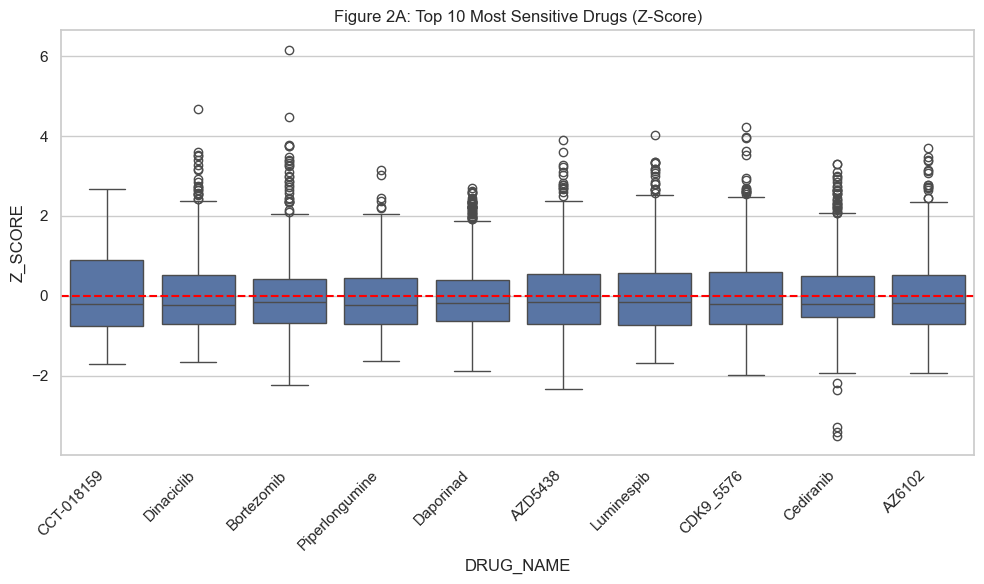

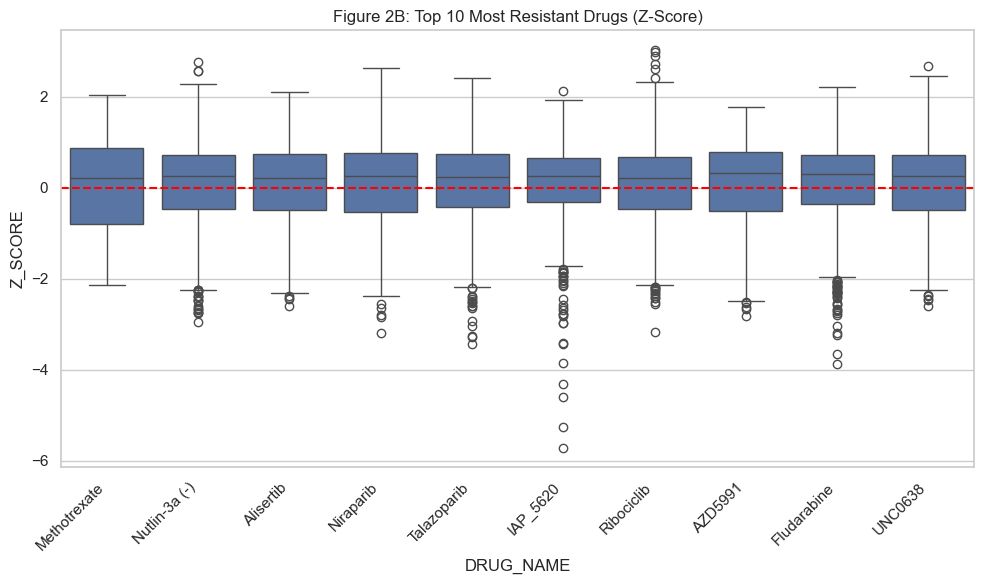

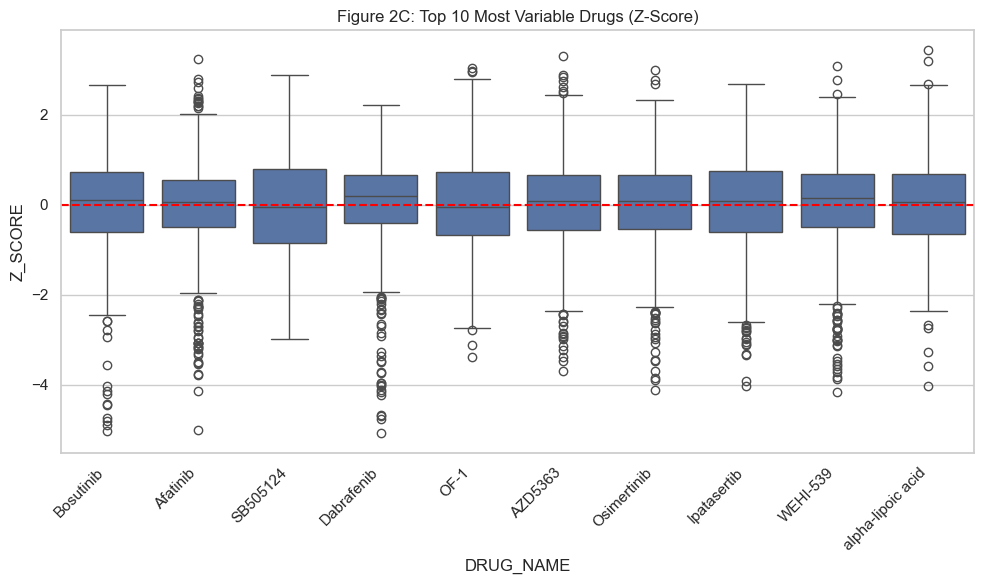

In [77]:
# Boxplot Z-Score Drug Distribution

# Top 10 most sensitive drugs (negative median Z-Score)
top_sensitive = median_zscore.head(10).index
subset_sensitive = gdsc[gdsc['DRUG_NAME'].isin(top_sensitive)]

plt.figure(figsize=(10,6))
sns.boxplot(data=subset_sensitive, x='DRUG_NAME', y='Z_SCORE')
plt.axhline(0, color='red', linestyle='--')  # zero reference line
plt.xticks(rotation=45, ha='right')
plt.title('Figure 2A: Top 10 Most Sensitive Drugs (Z-Score)')
plt.tight_layout()
plt.savefig("figures/Figure2A_SensitiveDrugs.png", dpi=300, bbox_inches="tight")
plt.show()

# Top 10 most resistant drugs (positive median Z-Score)
top_resistant = median_zscore.tail(10).index
subset_resistant = gdsc[gdsc['DRUG_NAME'].isin(top_resistant)]

plt.figure(figsize=(10,6))
sns.boxplot(data=subset_resistant, x='DRUG_NAME', y='Z_SCORE')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Figure 2B: Top 10 Most Resistant Drugs (Z-Score)')
plt.tight_layout()
plt.savefig("figures/Figure2B_ResistantDrugs.png", dpi=300, bbox_inches="tight")
plt.show()

# Top 10 most variable drugs (highest std deviation of Z-Score)
top_variable = std_zscore.head(10).index
subset_variable = gdsc[gdsc['DRUG_NAME'].isin(top_variable)]

plt.figure(figsize=(10,6))
sns.boxplot(data=subset_variable, x='DRUG_NAME', y='Z_SCORE')
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Figure 2C: Top 10 Most Variable Drugs (Z-Score)')
plt.tight_layout()
plt.savefig("figures/Figure2C_VariableDrugs.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 2A-C. Z‑Score distributions for drug sensitivity.**

Boxplots showing the top 10 most sensitive (2A), resistant (2B), and variable (2C) drugs. 
X‑axis = drug name, Y‑axis = Z‑Score. 
The red dashed line at Z‑Score = 0 marks average sensitivity.

(A) Top 10 most sensitive drugs, showing negative median Z‑Scores that indicate stronger‑than‑average responses across cell lines.  
(B) Top 10 most resistant drugs, with positive median Z‑Scores reflecting weaker‑than‑average responses.  
(C) Top 10 most variable drugs, highlighting compounds with the greatest spread in Z‑Scores, which suggests heterogeneous responses across different cancer cell lines. 


### Interpretation

In Figure 2A-C, median Z-Scores were calculated to validate drug sensitivity patterns identified using LN_IC50 and AUC. Negative Z-Scores indicate stronger-than-average sensitivity, whereas positive Z-Scores indicate weaker responses.

The most sensitive drugs included Piperlongumine, Dinaciclib, CCT-018159, Cediranib, CDK9_5576, Daporinad, and Bortezomib. In contrast, AZD5991, Fludarabine, IAP_5620, Niraparib, Nutlin-3a (−), and Talazoparib exhibited the highest median Z-Scores, indicating relatively weaker responses across the dataset.

These results provide an additional standardized perspective on drug sensitivity across cancer cell lines.

## 4.5 Variability in Drug Response Based on Z-Scores

The standard deviation of Z-Scores was calculated to assess variability in drug response after standardization. Bosutinib, Afatinib, SB505124, Alpha-lipoic acid, and WEHI-539 exhibited the largest Z-Score variation.

The large variability observed for these compounds suggests that drug response differs substantially across cancer types, with some cancers showing strong sensitivity while others appear resistant.

These findings further support the importance of precision medicine approaches that account for biological differences between tumors.

# 5. Cancer Cell Line Analysis

Research Questions
1. Do certain cancer types respond better to specific drugs?
2. What patterns exist in drug response across cancer cell lines?

## 5.1 Overall Cancer-Type Sensitivity

In [78]:
# Median LN_IC50 per cancer type

cancer_response_LNIC50 = (
    gdsc.groupby('TCGA_DESC')['LN_IC50']
        .median()
        .sort_values()
)

print(cancer_response_LNIC50.head(10))
print(cancer_response_LNIC50.tail(10))


TCGA_DESC
CLL     1.553044
LAML    2.043654
ALL     2.063221
DLBC    2.096066
LCML    2.162442
MM      2.470976
ACC     2.819815
NB      2.851345
MB      2.939177
HNSC    3.119146
Name: LN_IC50, dtype: float64
TCGA_DESC
LUSC    3.593490
OV      3.594032
LGG     3.643098
THCA    3.668516
PRAD    3.681222
LUAD    3.732755
LIHC    3.828824
UCEC    3.843761
MESO    3.860915
PAAD    4.165059
Name: LN_IC50, dtype: float64


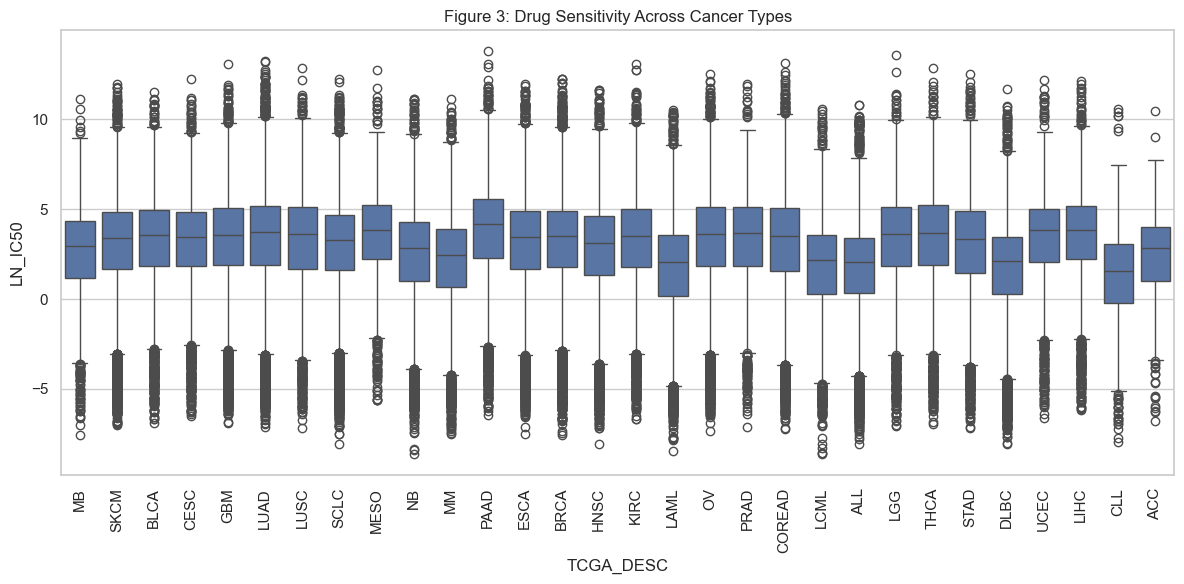

In [79]:
# Boxplot: Drug Sensitivity Across Cancer Types

plt.figure(figsize=(12,6))

sns.boxplot(
    data=gdsc,
    x='TCGA_DESC',
    y='LN_IC50'
)

plt.xticks(rotation=90)
plt.title('Figure 3: Drug Sensitivity Across Cancer Types')

plt.tight_layout()  # ensures labels and title fit nicely
#plt.savefig("figures/Figure3_CancerType_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 3. Drug sensitivity across cancer types.**

Boxplots showing LN_IC50 distributions for the 40 most represented cancer types. 
X‑axis = cancer type (TCGA codes), Y‑axis = LN_IC50. Lower values indicate greater sensitivity, higher values indicate resistance.



### Interpretation

Figure 3 shows that the median LN_IC50 values revealed substantial differences in drug sensitivity across cancer types.

The most sensitive cancer types were chronic lymphocytic leukemia (CLL), acute myeloid leukemia (LAML), acute lymphoblastic leukemia (ALL), diffuse large B-cell lymphoma (DLBC), chronic myelogenous leukemia (LCML), and multiple myeloma (MM), all of which exhibited relatively low median LN_IC50 values.

Conversely, pancreatic adenocarcinoma (PAAD), mesothelioma (MESO), uterine corpus endometrial carcinoma (UCEC), liver hepatocellular carcinoma (LIHC), and prostate adenocarcinoma (PRAD) showed the highest median LN_IC50 values, indicating greater resistance to treatment.

These findings suggest that hematological malignancies generally respond better to drug treatment than many solid tumors. However, results for CLL should be interpreted cautiously, as only two cell lines were available for analysis.


## 5.2 Best Drug per Cancer Type

In [80]:
best_drugs_per_cancer = (
    gdsc.groupby(['TCGA_DESC','DRUG_NAME'])['LN_IC50']
    .median()
    .reset_index()
)

best_drugs_per_cancer = (
    best_drugs_per_cancer
    .sort_values('LN_IC50')
    .groupby('TCGA_DESC')
    .first()
)

best_drugs_per_cancer

,DRUG_NAME,LN_IC50
TCGA_DESC,,
ACC,Sepantronium bromide,-6.290728
ALL,Daporinad,-6.807383
BLCA,Romidepsin,-5.104669
BRCA,Bortezomib,-5.396055
CESC,Romidepsin,-5.390980
CLL,SN-38,-6.780262
COREAD,Romidepsin,-4.735469
DLBC,Romidepsin,-5.995792
ESCA,Romidepsin,-5.264430


### Interpretation

To identify the most effective drug for each cancer type, the drug with the lowest median LN_IC50 was selected within each cancer group.

Hematological malignancies showed particularly strong responses to specific therapies. LCML was most sensitive to Dasatinib (LN_IC50 = −7.02), MM to Bortezomib (−5.62), ALL to Daporinad (−6.81), CLL to SN-38 (−6.78), and LAML to Vinblastine (−5.98).

Among solid tumors, Romidepsin emerged as the most effective drug across several cancer types, including BLCA, CESC, COREAD, GBM, HNSC, LUAD, LUSC, SKCM, STAD, and THCA. Sepantronium bromide was the most active drug in ACC and OV, while Bortezomib showed the strongest activity in BRCA and KIRC.

These findings demonstrate substantial cancer-type-specific drug sensitivity. While some drugs exhibited broad activity across multiple cancers, others showed strong selectivity, reinforcing the importance of precision oncology approaches.


## 5.3 Drug Response Patterns across Cancer Types

In [81]:
# Top 15 most potent drugs
top_drugs = (
    gdsc.groupby('DRUG_NAME')['LN_IC50']
    .median()
    .sort_values()
    .head(15)
    .index
)

heatmap_data = (
    gdsc[gdsc['DRUG_NAME'].isin(top_drugs)]
    .pivot_table(
        values='LN_IC50',
        index='TCGA_DESC',
        columns='DRUG_NAME',
        aggfunc='median'
    )
)

print(heatmap_data)

DRUG_NAME  Bortezomib  Camptothecin  Dactinomycin  Daporinad  Dinaciclib  \
TCGA_DESC                                                                  
ACC         -5.400538     -4.146297     -5.103222  -4.169611   -3.829886   
ALL         -5.603096     -4.608915     -4.973734  -6.807383   -3.885022   
BLCA        -4.941210     -2.949809     -4.112364  -4.699127   -3.076354   
BRCA        -5.396055     -0.969800     -3.063657  -2.951187   -2.821047   
CESC        -4.126798     -2.669153     -3.475471  -3.521974   -2.932016   
CLL         -5.922414     -5.207945     -6.424785  -5.618587   -4.280220   
COREAD      -4.552758     -1.963383     -3.369191  -3.807262   -2.297305   
DLBC        -5.702350     -4.359843     -5.851802  -5.735427   -4.096254   
ESCA        -4.892554     -1.401561     -3.515796  -4.446368   -2.970313   
GBM         -5.034078     -2.391755     -3.979404  -3.292528   -2.782188   
HNSC        -5.041309     -2.765455     -4.405552  -3.700811   -3.296536   
KIRC        

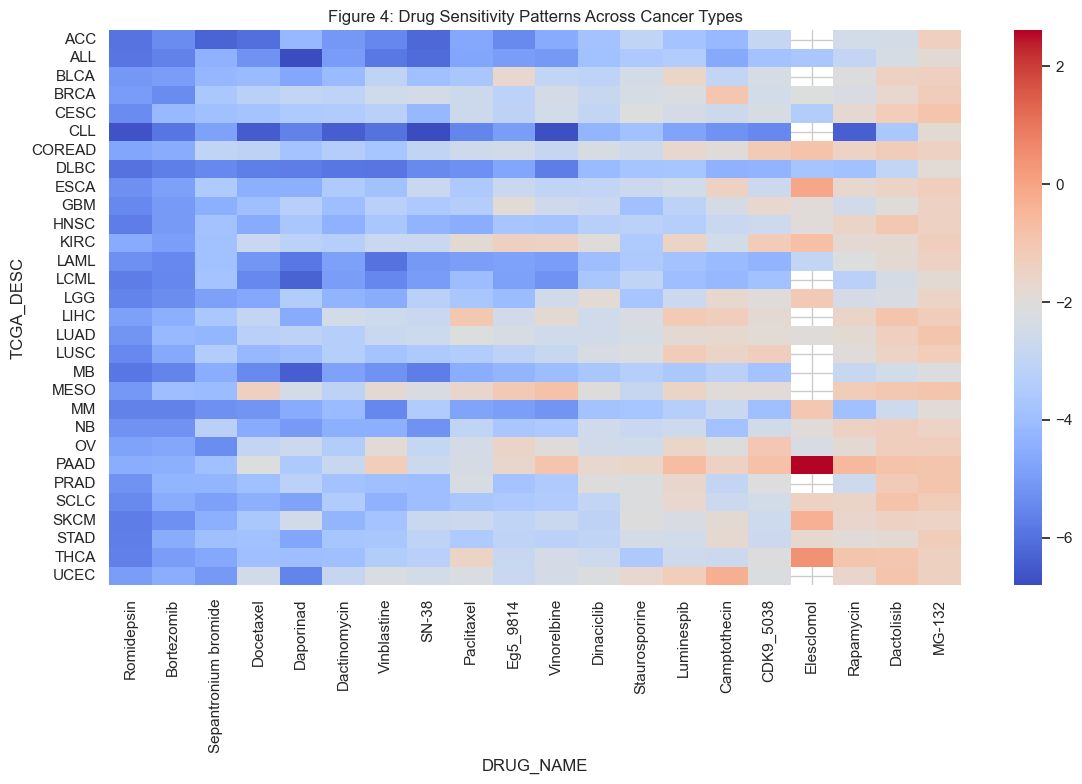

In [127]:
# Heatmap for drug sensitivity pattern

top_drugs = (
    gdsc.groupby('DRUG_NAME')['LN_IC50']
    .median()
    .sort_values()
    .head(20)
    .index
)

pivot_subset = gdsc.pivot_table(
    values='LN_IC50',
    index='TCGA_DESC',
    columns='DRUG_NAME',
    aggfunc='median'
)[top_drugs]

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_subset,
    cmap='coolwarm'
)

plt.title('Figure 4: Drug Sensitivity Patterns Across Cancer Types')
plt.tight_layout()
plt.savefig("figures/Figure4_DrugSensitivityHeatmap.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 4. Drug sensitivity patterns across cancer types.**

Heatmap showing median LN_IC50 values for the 20 most effective drugs across cancer types. 
X‑axis = drug name, Y‑axis = cancer type (TCGA codes). Colors range from blue (lower LN_IC50, greater sensitivity) through orange/light red (moderate sensitivity) to deep red (higher LN_IC50, greater resistance).


### Interpretation

in Figure 4, the heatmap revealed two major patterns of drug response.

First, several drugs exhibited broad activity across multiple cancer types. Drugs such as Bortezomib, Daporinad, Romidepsin, Dactinomycin, Docetaxel, and SN-38 consistently showed low LN_IC50 values across many cancer groups, indicating strong and widespread anticancer activity.

Second, some drugs displayed selective activity, producing strong responses in certain cancer types while showing limited effectiveness in others. This pattern highlights the biological heterogeneity of cancer and suggests that drug response is highly dependent on tumor-specific molecular characteristics.

Overall, hematological malignancies clustered among the most sensitive cancer types, whereas several solid tumors exhibited greater resistance across many treatments.


## 5.4 Cancer-Type-Selective Drug Responses

In [88]:
# Create pivot table: median LN_IC50 per cancer type × drug
pivot = gdsc.pivot_table(
    values='LN_IC50',
    index='TCGA_DESC',
    columns='DRUG_NAME',
    aggfunc='median'
)

# Calculate drug selectivity (range of LN_IC50 across cancer types)
drug_selectivity = (pivot.max() - pivot.min()).sort_values(ascending=False)

# Show top 10 most selective drugs
drug_selectivity.head(10)


DRUG_NAME
Dasatinib       10.501501
Nilotinib        9.122144
Gemcitabine      8.363108
AZD5991          8.019780
Bosutinib        7.846102
Tozasertib       7.655190
Sapitinib        6.900246
Cytarabine       6.657155
Methotrexate     6.442208
Alisertib        6.395927
dtype: float64

In [90]:
# Top most cancer selective drugs 

results = []

for drug in drug_selectivity.head(10).index:

    results.append([
        drug,
        pivot[drug].idxmin(),
        round(pivot[drug].min(), 2),
        pivot[drug].idxmax(),
        round(pivot[drug].max(), 2),
        round(pivot[drug].max() - pivot[drug].min(), 2)
    ])

selective_drugs = pd.DataFrame(
    results,
    columns=[
        'Drug',
        'Most Sensitive Cancer',
        'Min LN_IC50',
        'Least Sensitive Cancer',
        'Max LN_IC50',
        'Range'
    ]
)

selective_drugs

,Drug,Most Sensitive Cancer,Min LN_IC50,Least Sensitive Cancer,Max LN_IC50,Range
0,Dasatinib,LCML,-7.02,SKCM,3.48,10.50
1,Nilotinib,LCML,-4.95,MESO,4.17,9.12
2,Gemcitabine,CLL,-5.16,UCEC,3.21,8.36
3,AZD5991,MM,-1.80,PAAD,6.22,8.02
4,Bosutinib,LCML,-3.94,GBM,3.90,7.85
5,Tozasertib,DLBC,-2.16,PAAD,5.49,7.66
6,Sapitinib,ACC,-1.22,PRAD,5.68,6.90
7,Cytarabine,ALL,-2.63,UCEC,4.03,6.66
8,Methotrexate,CLL,-3.40,LGG,3.04,6.44
9,Alisertib,CLL,-2.71,PRAD,3.69,6.40


### Interpretation

To further investigate cancer-specific drug activity, a selectivity analysis was performed by calculating the range of median LN_IC50 values across cancer types for each drug. Drugs with larger ranges demonstrated greater variation in response and were considered more cancer-type selective.

Dasatinib showed the highest selectivity, displaying strong sensitivity in chronic myelogenous leukemia (LCML) but substantially weaker activity in skin cutaneous melanoma (SKCM). Similarly, Nilotinib exhibited marked sensitivity in LCML while showing limited activity in mesothelioma (MESO). AZD5991 was particularly effective in multiple myeloma (MM) but considerably less effective in pancreatic adenocarcinoma (PAAD). Gemcitabine also demonstrated selective activity, showing strong responses in chronic lymphocytic leukemia (CLL) and weaker responses in uterine corpus endometrial carcinoma (UCEC).

These findings indicate that some drugs have broad activity across multiple cancer types, whereas others demonstrate strong cancer-type-specific responses that may be linked to underlying molecular and biological differences.

## 5.5 Summary Interpretation

Overall, substantial heterogeneity in drug response was observed across cancer cell lines. Hematological malignancies, including ALL, LAML, DLBC, LCML, and MM, consistently demonstrated greater sensitivity to treatment, whereas several solid tumors such as PAAD, LIHC, PRAD, and MESO showed increased resistance.

Heatmap analysis revealed both broadly effective drugs and highly selective compounds whose activity depended strongly on cancer type. The identification of cancer-type-selective drugs, including Dasatinib, Nilotinib, Gemcitabine, AZD5991, and Cytarabine, further highlights the importance of matching therapies to the biological characteristics of specific cancers.

These findings support the principles of precision oncology, where treatment decisions are guided by tumor-specific molecular and biological features rather than a one-size-fits-all approach.

# 6. Genomic, Transcriptomic and Epigenomic Influence on Drug Response

Research Question

Are mutations (CNA), gene expression or methylation level influencing drug sensitivity at all?

To investigate the influence of molecular features on drug response, drug sensitivity metrics (LN_IC50 and AUC) were compared across Copy Number Alteration (CNA), Gene Expression, and Methylation groups.
##### Figure 5. Genomic, transcriptomic and epigenomic influences on drug response (A–F)
Figure 5A–F compare drug sensitivity across molecular characteristics, including copy number alteration (CNA), gene expression status, and methylation status, using LN_IC50 and AUC metrics. Lower LN_IC50 and AUC values indicate greater drug sensitivity. These visualizations evaluate whether genomic, transcriptomic, and epigenomic factors are associated with differences in treatment response.

## 6.1 Do Copy Number Alterations (CNA) Influence Drug Sensitivity (LN_IC50)?

In [91]:
# CNA vs LN_IC50

cna_sensitivity_LN_IC50 = gdsc.groupby('CNA')['LN_IC50'].agg(['mean', 'median', 'count'])
cna_sensitivity_LN_IC50

,mean,median,count
CNA,,,
N,3.128990,3.508225,658
Y,2.821395,3.269899,161445


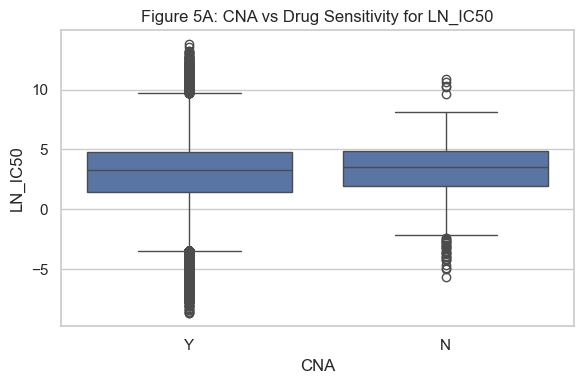

In [92]:
# Boxplot: CNA vs LN_IC50

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='CNA', y='LN_IC50')
plt.title('Figure 5A: CNA vs Drug Sensitivity for LN_IC50')
plt.tight_layout()
#plt.savefig("figures/Figure5A_CNA_vs_LN_IC50.png", dpi=300, bbox_inches="tight")
plt.show()

In [93]:
# CNA vs AUC

cna_sensitivity_AUC = gdsc.groupby('CNA')['AUC'].agg(['mean', 'median', 'count'])
cna_sensitivity_AUC


,mean,median,count
CNA,,,
N,0.894110,0.934921,658
Y,0.879866,0.941490,161445


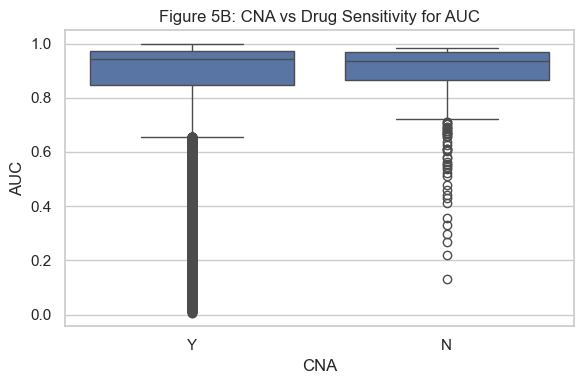

In [94]:
# Boxplot: CNA vs AUC

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='CNA', y='AUC')
plt.title('Figure 5B: CNA vs Drug Sensitivity for AUC')
plt.tight_layout()
#plt.savefig("figures/Figure5B_CNA_vs_AUC.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 5A–B. Association between copy number alterations (CNA) and drug sensitivity.** 

(A) Boxplots comparing LN_IC50 distributions in samples with (Y) and without (N) CNA. 
X‑axis = CNA status (Y/N), Y‑axis = LN_IC50.  
(B) Boxplots comparing AUC distributions in samples with (Y) and without (N) CNA. 
X‑axis = CNA status (Y/N), Y‑axis = AUC. Median values are similar, but CNA‑positive samples show greater variability and more extreme outliers.


### Interpretation 

Cell lines with copy number alterations (CNA = Y; n = 161,445) showed slightly lower median LN_IC50 values (3.27) than CNA-negative cell lines (n = 658; median LN_IC50 = 3.51). Similarly, the mean AUC was lower in CNA-positive cell lines (0.880) than in CNA-negative cell lines (0.894).

The corresponding boxplots showed substantial overlap between the two groups, indicating that although the effect size was modest, CNA-positive cell lines generally exhibited greater drug sensitivity.

These findings suggest that the presence of copy number alterations is associated with increased drug sensitivity across the dataset.

Outliers highlight heterogeneity in drug response.

## 6.2 Gene Expression and Drug Sensitivity

In [95]:
# Gene Expression vs LN_IC50

gene_expression_LN_IC50 = gdsc.groupby('Gene Expression')['LN_IC50'].agg(['mean', 'median', 'count'])
gene_expression_LN_IC50

,mean,median,count
Gene Expression,,,
N,2.377815,2.830496,3761
Y,2.833210,3.283111,158342


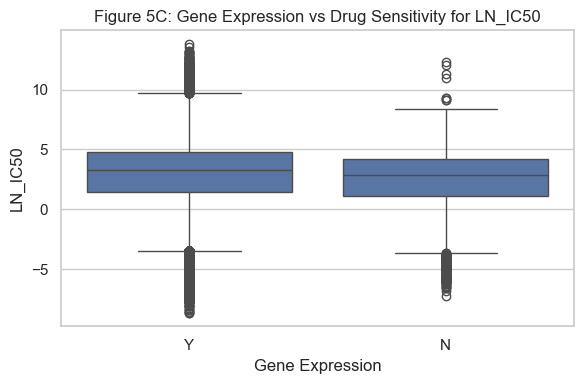

In [96]:
# Boxplot: Gene Expression vs LN_IC50

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='Gene Expression', y='LN_IC50')
plt.title('Figure 5C: Gene Expression vs Drug Sensitivity for LN_IC50')
plt.tight_layout()
#plt.savefig("figures/Figure5C_GeneExpression_vs_LN_IC50.png", dpi=300, bbox_inches="tight")
plt.show()

In [97]:
# Gene Expression vs AUC
gene_expression_AUC = gdsc.groupby('Gene Expression')['AUC'].agg(['mean', 'median', 'count'])
gene_expression_AUC

,mean,median,count
Gene Expression,,,
N,0.859263,0.926015,3761
Y,0.880415,0.941758,158342


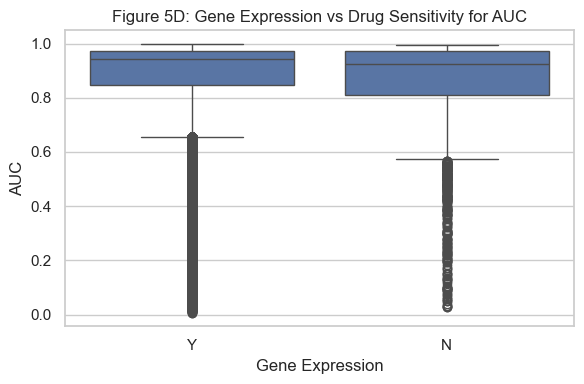

In [98]:
# Boxplot: Gene Expression vs AUC

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='Gene Expression', y='AUC')
plt.title('Figure 5D: Gene Expression vs Drug Sensitivity for AUC')
plt.tight_layout()
plt.savefig("figures/Figure5D_GeneExpression_vs_AUC.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 5C-D. Association between gene expression and drug sensitivity.** 

(C) Boxplots comparing LN_IC50 distributions in samples with (Y) and without (N) gene expression. 
X‑axis = CNA status (Y/N), Y‑axis = LN_IC50.
Lower LN_IC50 values indicate greater sensitivity, while higher values reflect relative resistance.
(D) Boxplots comparing AUC distributions in samples with (Y) and without (N) gene expression.
X‑axis = CNA status (Y/N), Y‑axis = AUC. Median AUC values are similar across groups, but both show variability and numerous outliers, with gene‑expressing samples (Y) displaying a wider spread.  

### Interpretation

Cell lines with gene expression events (Y; n = 158,342) exhibited higher median LN_IC50 values (3.28) than cell lines without gene expression events (N; n = 3,761; median LN_IC50 = 2.83). Mean AUC values were also higher in the gene-expression-positive group (0.880) compared with the negative group (0.859).

The boxplots demonstrated a slight upward shift in the distribution of LN_IC50 and AUC values among gene-expression-positive cell lines, suggesting reduced drug sensitivity.

This pattern indicates an association between gene expression status and reduced sensitivity to multiple drug treatments and may contribute to resistance across cancer cell lines.

## 6.3 Methylation and Drug Sensitivity

In [99]:
# Methylation vs LN_IC50

methylation_sensitivity_LN_IC50 = gdsc.groupby('Methylation')['LN_IC50'].agg((['mean', 'median', 'count']))
methylation_sensitivity_LN_IC50

,mean,median,count
Methylation,,,
N,2.796813,3.211147,3502
Y,2.823214,3.272621,158601


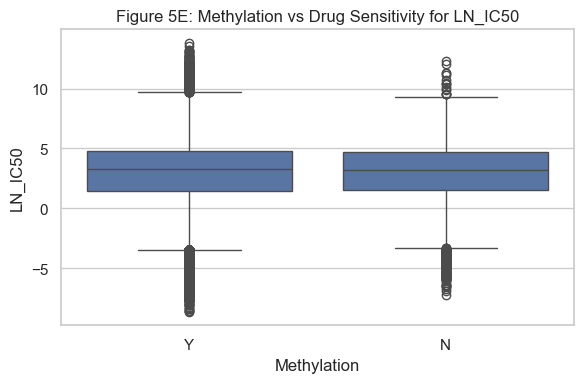

In [100]:
# Boxplot: Methylation vs LN_IC50

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='Methylation', y='LN_IC50')
plt.title('Figure 5E: Methylation vs Drug Sensitivity for LN_IC50')
plt.tight_layout()
plt.savefig("figures/Figure5E_Methylation_vs_LN_IC50.png", dpi=300, bbox_inches="tight")
plt.show()

In [101]:
# Methylation vs AUC

methylation_sensitivity_AUC = gdsc.groupby('Methylation')['AUC'].agg((['mean', 'median', 'count']))
methylation_sensitivity_AUC

,mean,median,count
Methylation,,,
N,0.873073,0.933706,3502
Y,0.880075,0.941611,158601


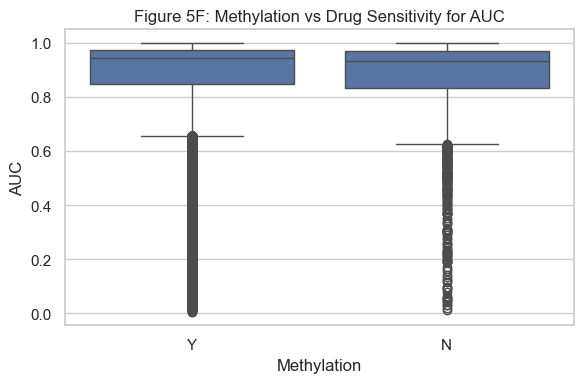

In [102]:
# Boxplot: Methylation vs AUC

plt.figure(figsize=(6,4))
sns.boxplot(data=gdsc, x='Methylation', y='AUC')
plt.title('Figure 5F: Methylation vs Drug Sensitivity for AUC')
plt.tight_layout()
plt.savefig("figures/Figure5F_Methylation_vs_AUC.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 5E-F.  Methylation and drug sensitivity.** 

(E) LN_IC50 distributions for samples with (Y) and without (N) methylation, where lower values indicate greater sensitivity. 
X‑axis = CNA status (Y/N), Y‑axis = LN_IC50.
(F) AUC distributions for the same groups, showing similar medians but more variability and outliers in non‑methylated samples. 
X‑axis = CNA status (Y/N), Y‑axis = AUC.  
Overall, methylation status is associated with differences in variability of drug response rather than shifts in median sensitivity.

### Interpretation

Methylated cell lines (Y; n = 158,601) exhibited a median LN_IC50 value of 3.27 compared with 3.21 in non-methylated cell lines (N; n = 3,502). Mean LN_IC50 values were also very similar between methylated (2.82) and non-methylated (2.80) cell lines. Likewise, mean AUC values differed only slightly between methylated (0.880) and non-methylated (0.873) cell lines.

The boxplots showed substantial overlap between the two groups, indicating minimal differences in overall drug response. 
These findings suggest that methylation status had only a modest influence on drug sensitivity at the global dataset level.

## 6.4 Overall Interpretation

The analysis demonstrates that genomic, transcriptomic, and epigenomic features are associated with differences in drug response. Copy number alterations were linked to slightly greater drug sensitivity, whereas gene expression status was associated with reduced sensitivity. In contrast, methylation showed only a modest overall effect.

These findings complement the cancer cell line analysis, which revealed substantial heterogeneity in drug response across cancer types. Together, the results suggest that variation in drug sensitivity may be influenced not only by cancer type but also by underlying molecular characteristics of the cancer cell lines.

Overall, the study supports the principles of precision oncology, where both tumor lineage and molecular profile can contribute to treatment response and may help guide the selection of more effective therapeutic strategies.

A limitation of this analysis is the substantial imbalance between molecular groups. For example, CNA-positive, gene-expression-positive, and methylated samples greatly outnumbered their corresponding negative groups. Therefore, these findings should be interpreted as broad associations rather than definitive evidence of causal relationships between molecular features and drug response.

# 7. Supporting Data Visualization

To complement the statistical analyses performed in previous sections, several visualizations were generated to explore the distribution of drug sensitivity measurements, compare responses across drugs and cancer types, and evaluate relationships among drug response metrics. These visualizations provide additional insight into patterns of sensitivity, resistance, and variability across the GDSC dataset.

##### Figure 6: Distribution, Comparison, and Correlation Analyses of Drug Sensitivity Metrics (A–F)
Figure 6A–F present complementary analyses of drug sensitivity using LN_IC50, AUC, and Z_SCORE metrics. The figures include Z-score distributions for sensitive, resistant, and highly variable drugs, boxplot comparisons across top-performing drugs and cancer types, and correlation analyses among major drug response measures. Together, these visualizations highlight patterns of drug effectiveness, variability, cancer-specific responses, and relationships among sensitivity metrics


## 7.1. Distribution Plots of Drug Sensitivity

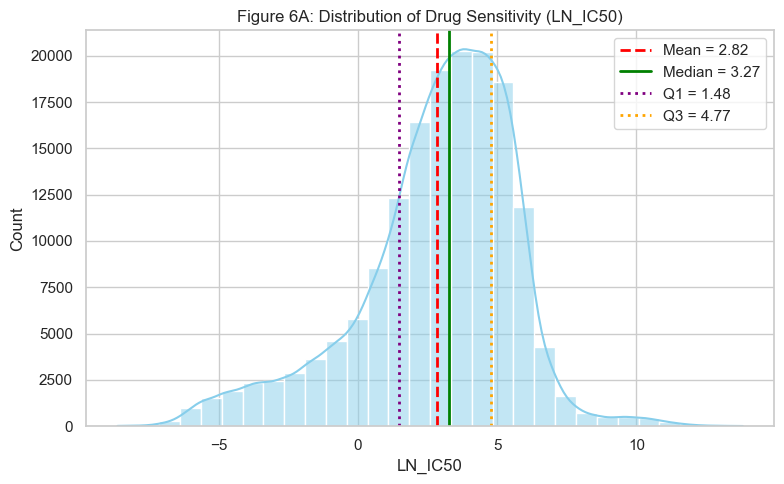

In [103]:
# Histoplot For LN_IC50

plt.figure(figsize=(8,5))
sns.histplot(gdsc['LN_IC50'], bins=30, kde=True, color='skyblue')

# Summary statistics
mean_val = gdsc['LN_IC50'].mean()
median_val = gdsc['LN_IC50'].median()
q1_val = gdsc['LN_IC50'].quantile(0.25)
q3_val = gdsc['LN_IC50'].quantile(0.75)

# Vertical lines
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
plt.axvline(q1_val, color='purple', linestyle=':', linewidth=2, label=f'Q1 = {q1_val:.2f}')
plt.axvline(q3_val, color='orange', linestyle=':', linewidth=2, label=f'Q3 = {q3_val:.2f}')

plt.title('Figure 6A: Distribution of Drug Sensitivity (LN_IC50)')
plt.xlabel('LN_IC50')
plt.ylabel('Count') 
plt.legend()
plt.tight_layout()
plt.savefig("figures/Figure6A_LN_IC50_Histogram.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 6A. Distribution of drug sensitivity (LN_IC50).** 

Histogram with density curve showing LN_IC50 values across cell lines. 
X‑axis = LN_IC50, Y‑axis = frequency. Mean (2.82), median (3.27), and quartiles (Q1 = 1.48, Q3 = 4.77) are indicated. The distribution is approximately normal with slight right skew, reflecting variability in drug potency.

### Interpretation

The Figure 6A histogram shows the frequency of LN_IC50 values across all drug–cancer pairs, with a kernel density estimate (KDE) curve highlighting the overall distribution. Vertical lines mark the mean (2.82, red dashed), median (3.27, green solid), and quartiles (Q1 = 1.48, purple; Q3 = 4.77, orange). The shaded region between Q1 and Q3 represents the interquartile range (IQR), where the middle 50% of drug responses lie. Values below Q1 indicate highly sensitive cancers/drugs, while values above Q3 indicate resistant cancers/drugs. 
The median being higher than the mean suggests a slight left-skew in the distribution, driven by a subset of highly sensitive drug–cancer combinations with very low LN_IC50 values.

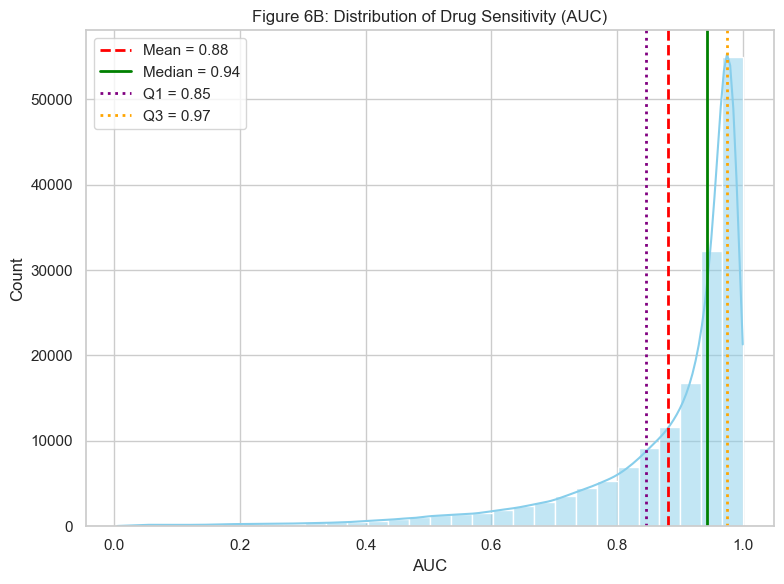

In [104]:
# Histogram for AUC

plt.figure(figsize=(8,6))
sns.histplot(gdsc['AUC'], bins=30, kde=True, color='skyblue')

# Summary statistics
mean_val = gdsc['AUC'].mean()
median_val = gdsc['AUC'].median()
q1_val = gdsc['AUC'].quantile(0.25)
q3_val = gdsc['AUC'].quantile(0.75)

# Vertical lines
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.2f}')
plt.axvline(q1_val, color='purple', linestyle=':', linewidth=2, label=f'Q1 = {q1_val:.2f}')
plt.axvline(q3_val, color='orange', linestyle=':', linewidth=2, label=f'Q3 = {q3_val:.2f}')

plt.title('Figure 6B: Distribution of Drug Sensitivity (AUC)')
plt.xlabel('AUC')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig("figures/Figure6B_AUC_Histogram.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 6B. Distribution of drug sensitivity (AUC).** 

Histogram with density curve showing AUC values across cell lines. 
X‑axis = AUC, Y‑axis = frequency. Mean (0.88), median (0.94), and quartiles (Q1 = 0.85, Q3 = 0.97) are indicated. The distribution is skewed toward higher values near 1.0, reflecting that most drugs achieve strong inhibition.



### Interpretation

The Figure 6B histogram shows the frequency of AUC values across all drug–cancer pairs, with a kernel density estimate (KDE) curve highlighting the overall distribution. Vertical lines mark the mean (0.88, red dashed), median (0.94, green solid), and quartiles (Q1 = 0.85, purple; Q3 = 0.97, orange). The shaded region between Q1 and Q3 represents the interquartile range (IQR), where the middle 50% of drug responses lie.

The clustering of AUC values near 1.0 indicates that many drug–cancer combinations showed limited overall inhibition, while a smaller subset of treatments achieved stronger responses reflected by lower AUC values.

The AUC distribution is concentrated toward higher values, indicating that many drug–cell line combinations exhibit relatively limited inhibition, while a smaller subset achieves stronger responses reflected by lower AUC values.

### Combined Biological Meaning

Together, LN_IC50 and AUC provide complementary insights:

LN_IC50 highlights how much drug is needed (sensitivity threshold).

AUC highlights how well the drug works overall (potency across doses).

The LN_IC50 distribution shows variation in sensitivity across cancers, while the AUC distribution shows consistently strong performance for most drugs.

Outliers in both plots (very low LN_IC50 or very low AUC) are critical — they identify either promising drug–cancer matches or cases of resistance that need alternative strategies.

## 7.2 Boxplots Comparing Drugs or Cancer Type

### a. Boxplots Comparing Drugs

In [105]:
drug_rank = gdsc.groupby('DRUG_NAME')['LN_IC50'].median().sort_values().head(20)
drug_rank


DRUG_NAME
Romidepsin             -5.317812
Bortezomib             -4.906318
Sepantronium bromide   -4.210507
Docetaxel              -3.990660
Daporinad              -3.902214
Dactinomycin           -3.820755
Vinblastine            -3.783500
SN-38                  -3.510652
Paclitaxel             -3.194081
Eg5_9814               -3.137055
Vinorelbine            -3.117927
Dinaciclib             -2.983147
Staurosporine          -2.667322
Luminespib             -2.402346
Camptothecin           -2.391764
CDK9_5038              -2.349072
Elesclomol             -1.893472
Rapamycin              -1.873709
Dactolisib             -1.577113
MG-132                 -1.359344
Name: LN_IC50, dtype: float64

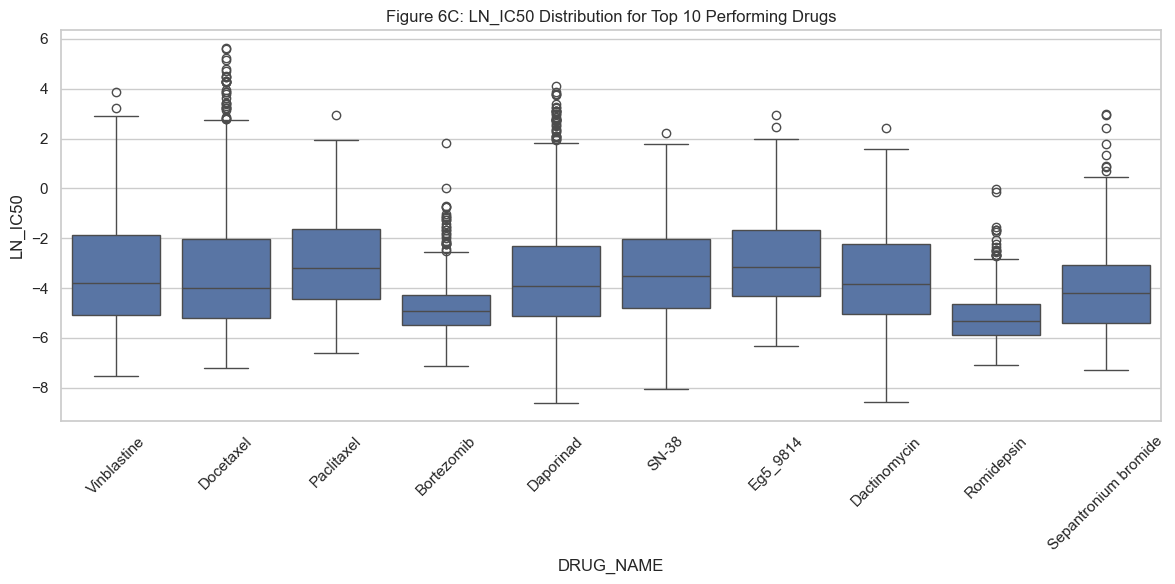

In [106]:
# Boxplot for Drug Ranking (Top 10 drugs by median LN_IC50)

# Rank all drugs by median LN_IC50
drug_rank = gdsc.groupby('DRUG_NAME')['LN_IC50'].median().sort_values()
top_drugs = drug_rank.head(10).index.tolist()

# Select top 10 drugs (lowest median LN_IC50)
plt.figure(figsize=(12,6))
sns.boxplot(
    data=gdsc[gdsc['DRUG_NAME'].isin(top_drugs)],
    x='DRUG_NAME',
    y='LN_IC50'
)

# Plot boxplots for these top 5 drugs
plt.xticks(rotation=45)
plt.title('Figure 6C: LN_IC50 Distribution for Top 10 Performing Drugs')
plt.tight_layout()
plt.savefig("figures/Figure6C_TopDrugs_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 6C. LN_IC50 distributions for top performing drugs.**

Boxplots showing LN_IC50 values for the most effective drugs. Lower LN_IC50 values indicate greater sensitivity, while variability across drugs highlights differences in potency and response consistency.


### Interpretation

The Figure 6C boxplot compare the LN_IC50 distributions of the 10 most potent drugs, ranked by median LN_IC50. Lower medians indicate stronger potency, while the spread reflects variability across cancer cell lines. 

Romidepsin, Bortezomib, and Dactinomycin display consistently low median LN_IC50 values, indicating strong potency across many cancer cell lines. In contrast, drugs such as SN-38 and Sepantronium bromide exhibit wider distributions, suggesting greater variability in response across cancer types.

These findings suggest that while some drugs demonstrate broadly effective activity, others exhibit more heterogeneous responses that may depend on cancer-specific biological characteristics.

### b. Boxplots Comparing Cancer Types

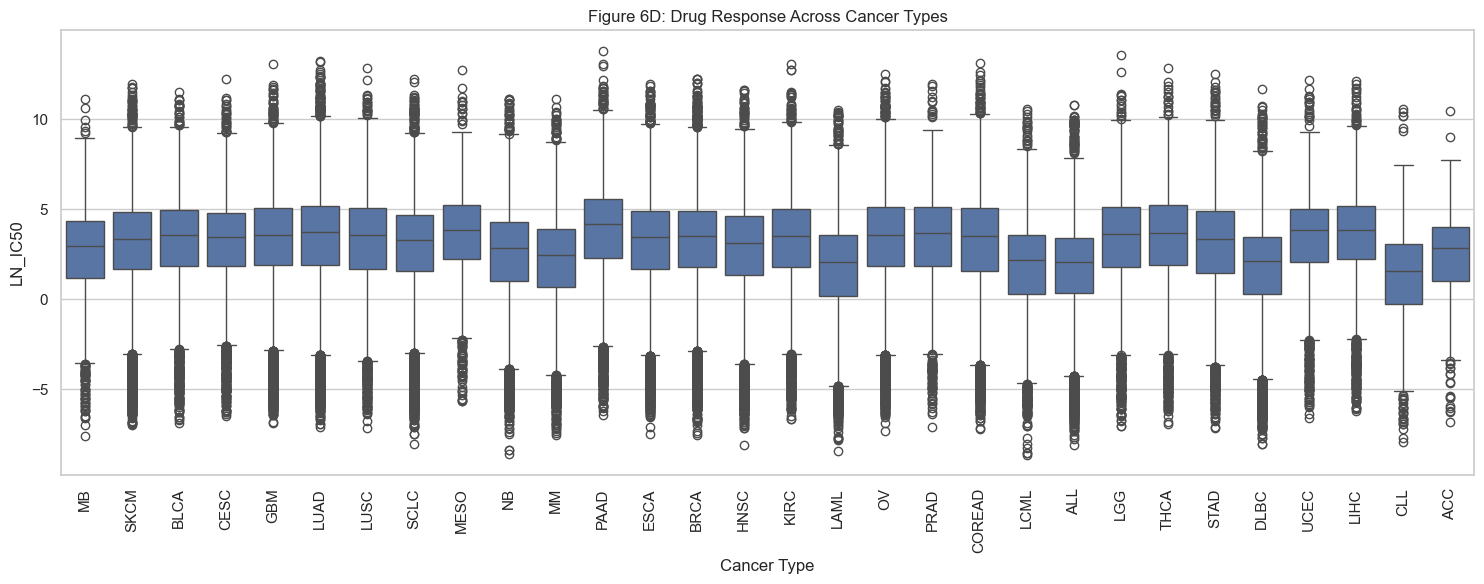

In [107]:
# Boxplot for top cancer types
top_cancers = gdsc['TCGA_DESC'].value_counts().head(40).index
plt.figure(figsize=(15,6))

sns.boxplot(
    data=gdsc[gdsc['TCGA_DESC'].isin(top_cancers)],
    x='TCGA_DESC',
    y='LN_IC50'
)
plt.xticks(rotation=90)
plt.title('Figure 6D: Drug Response Across Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('LN_IC50')
plt.tight_layout()
plt.savefig("figures/Figure6D_CancerTypes_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 6D. Drug response across cancer types.** 

Boxplots showing LN_IC50 values across cancer types. X‑axis = cancer type (TCGA codes), Y‑axis = LN_IC50. Lower values indicate greater sensitivity, higher values reflect resistance, highlighting variability in treatment response.



### Interpretation

The Figure 6D boxplots compare LN_IC50 distributions across the 40 most represented cancer types. Lower medians indicate stronger drug sensitivity, while wider spreads reflect variability among samples. 

Hematological malignancies such as CLL, LAML, ALL, DLBC, LCML, and MM generally exhibit lower median LN_IC50 values, indicating greater sensitivity to treatment. In contrast, PAAD, LIHC, UCEC, and MESO display higher median values, suggesting increased resistance to treatment.

Outliers highlight exceptional cases of sensitivity or resistance within each cancer type.

# 7.3 Scatter Plots Showing Relationships (LN_IC50 vs AUC)

Correlation coefficient: 0.7604472117287252


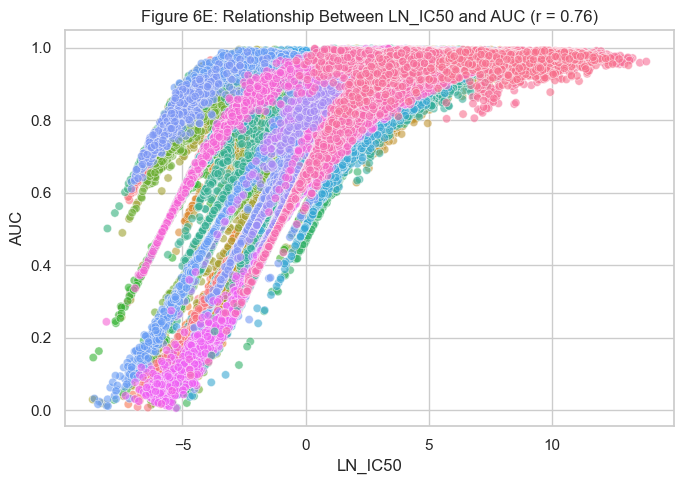

In [108]:
# Scatterplot: LN_IC50 vs AUC
from scipy.stats import pearsonr

# Calculate correlation
r, p = pearsonr(gdsc['LN_IC50'], gdsc['AUC'])
print("Correlation coefficient:", r)

plt.figure(figsize=(7,5))
sns.scatterplot(x='LN_IC50', y='AUC', data=gdsc, hue='DRUG_NAME', alpha=0.6, legend=False)

plt.title(f'Figure 6E: Relationship Between LN_IC50 and AUC (r = {r:.2f})')
plt.xlabel('LN_IC50')
plt.ylabel('AUC')
plt.tight_layout()
plt.savefig("figures/Figure6E_LN_IC50_vs_AUC_Scatter.png", dpi=300, bbox_inches="tight")
plt.show()


**Figure 6E. LN_IC50 vs AUC.**  

Scatter plot showing the relationship between LN_IC50 (x‑axis) and AUC (y‑axis). Data points are colored by drug/cell line groups, illustrating a strong positive correlation (r = 0.76).



### Interpretation

The Figure 6E scatter plot analysis revealed a strong positive relationship between LN_IC50 and AUC (r ≈ 0.76). Drug–cell line combinations with higher LN_IC50 values generally exhibited higher AUC values, indicating lower sensitivity and reduced drug effectiveness.

The strong correlation between these two measures confirms that they capture related aspects of drug response. At the same time, the spread of points around the overall trend reflects biological variability among different drugs and cancer cell lines.

## 7.4 Correlations

          LN_IC50       AUC   Z_SCORE
LN_IC50  1.000000  0.760447  0.501577
AUC      0.760447  1.000000  0.443160
Z_SCORE  0.501577  0.443160  1.000000


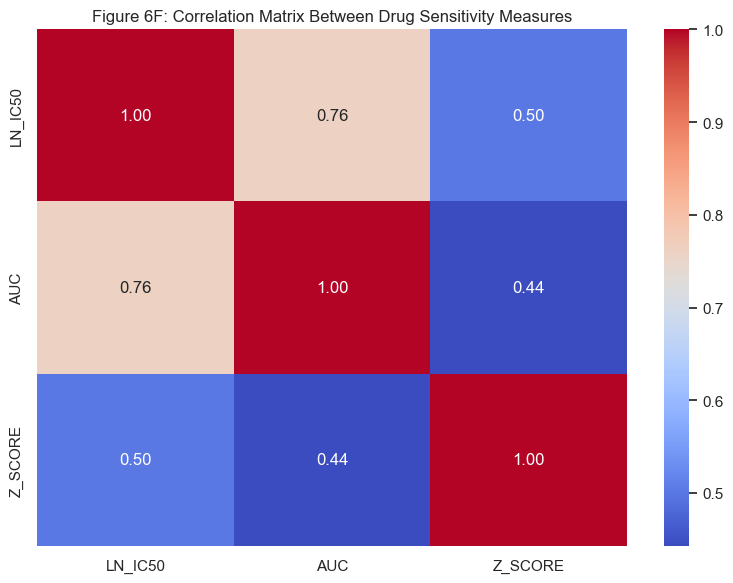

In [109]:
# Correlation Heatmap

corr = gdsc[['LN_IC50', 'AUC', 'Z_SCORE']].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Figure 6F: Correlation Matrix Between Drug Sensitivity Measures')
plt.tight_layout()
plt.savefig("figures/Figure6F_CorrelationHeatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 6F. Correlation matrix of drug sensitivity measures.** 

Heatmap showing pairwise correlations among LN_IC50, AUC, and Z_SCORE. Colors range from blue (lower correlation) to red (higher correlation), with values from 0.5 to 1.0.

### Interpretation

The Figure 6F heatmap showing correlations among LN_IC50, AUC, and Z_SCORE. LN_IC50 and AUC are strongly correlated (r ≈ 0.76), indicating they capture similar aspects of drug potency and efficacy. LN_IC50 and Z_SCORE show moderate correlation (r ≈ 0.50), while AUC and Z_SCORE are more weakly correlated (r ≈ 0.44). Together, these measures provide complementary perspectives on drug response.

## 7.5 Correlation Analysis

Correlation analysis was performed using LN_IC50, AUC, and Z_SCORE to evaluate relationships among the major drug sensitivity metrics. 

The strongest relationship was observed between LN_IC50 and AUC (r ≈ 0.76), indicating that both metrics consistently measure drug sensitivity and effectiveness. Moderate correlations were observed between LN_IC50 and Z_SCORE (r ≈ 0.50) and between AUC and Z_SCORE (r ≈ 0.44).

These findings suggest that LN_IC50 and AUC capture similar aspects of drug response, while Z_SCORE provides additional standardized information that facilitates comparisons across drugs and cell lines.

# 8. Additional Molecular and Biological Influences on Drug Response

##  8.1 MSI Analysis
Are MSI-H tumors more sensitive than MSS tumors?

In [110]:
gdsc['Microsatellite instability Status (MSI)'].value_counts

<bound method IndexOpsMixin.value_counts of 0         MSS/MSI-L
1         MSS/MSI-L
2         MSS/MSI-L
3         MSS/MSI-L
4         MSS/MSI-L
            ...    
162098    MSS/MSI-L
162099        MSI-H
162100        MSI-H
162101    MSS/MSI-L
162102        MSI-H
Name: Microsatellite instability Status (MSI), Length: 162103, dtype: str>

In [111]:
gdsc.groupby(
    'Microsatellite instability Status (MSI)'
)['LN_IC50'].agg(['median','mean','count'])

,median,mean,count
Microsatellite instability Status (MSI),,,
MSI-H,2.996535,2.558463,11322
MSS/MSI-L,3.293239,2.842481,150781


In [112]:
gdsc.groupby(
    'Microsatellite instability Status (MSI)'
)['AUC'].agg(['median','mean','count'])

,median,mean,count
Microsatellite instability Status (MSI),,,
MSI-H,0.938550,0.873346,11322
MSS/MSI-L,0.941633,0.880418,150781


### Interpretation

Microsatellite instability (MSI) status was evaluated to determine its influence on drug response. Comparison of LN_IC50 values showed that MSI-H cell lines were generally more sensitive to treatment than MSS/MSI-L cell lines. MSI-H samples had a lower median LN_IC50 (2.997) compared with MSS/MSI-L samples (3.293), indicating that lower drug concentrations were required to inhibit growth.

A similar trend was observed for AUC values, where MSI-H cell lines showed slightly lower median AUC values (0.939) than MSS/MSI-L cell lines (0.942). Together, these findings suggest that tumors with high microsatellite instability tend to be more responsive to anticancer therapies (Yang et al., 2013).

The increased sensitivity of MSI-H cancers may be related to their underlying genomic instability, which can make them more vulnerable to therapeutic intervention.

## 8.2  Statistical Significance Testing

In [113]:
# MSI-H vs MSS

from scipy.stats import mannwhitneyu

msi_h = gdsc[
    gdsc['Microsatellite instability Status (MSI)']=="MSI-H"
]['LN_IC50']

mss = gdsc[
    gdsc['Microsatellite instability Status (MSI)']=="MSS/MSI-L"
]['LN_IC50']

stat,p = mannwhitneyu(msi_h,mss)

print(p)

3.8078404168508164e-32


### Interpretation

A Mann–Whitney U test revealed a highly significant difference in LN_IC50 values between MSI-H and MSS/MSI-L cell lines (p = 3.81 × 10⁻³²), confirming that microsatellite instability status is significantly associated with drug sensitivity.

# 8.3 Growth Properties Analysis
Do suspension-growing cancers respond differently from adherent cancers?

In [114]:
gdsc['Growth Properties'].value_counts()

Growth Properties
Adherent         122381
Suspension        34884
Semi-Adherent      4838
Name: count, dtype: int64

In [115]:
gdsc.groupby(
    'Growth Properties'
)['LN_IC50'].agg(['median','mean','count'])

,median,mean,count
Growth Properties,,,
Adherent,3.520082,3.075431,122381
Semi-Adherent,3.335541,2.873732,4838
Suspension,2.441651,1.928724,34884


In [116]:
gdsc.groupby(
    'Growth Properties'
)['AUC'].agg(['median','mean','count'])         

,median,mean,count
Growth Properties,,,
Adherent,0.942631,0.888505,122381
Semi-Adherent,0.945868,0.883926,4838
Suspension,0.934365,0.849265,34884


### Interpretation

Drug sensitivity was also examined according to cell growth characteristics. Suspension-growing cell lines displayed substantially greater sensitivity than adherent cell lines. Suspension cell lines had the lowest median LN_IC50 value (2.44), followed by semi-adherent cell lines (3.34), while adherent cell lines showed the highest median LN_IC50 value (3.52).

The same pattern was observed for AUC, where suspension cell lines exhibited lower median AUC values (0.934) compared with adherent (0.943) and semi-adherent (0.946) cell lines.

These findings suggest that suspension-growing cancers, which are predominantly hematological malignancies, are generally more responsive to treatment than adherent solid tumors. This observation is consistent with earlier analyses showing that leukemia and lymphoma cell lines were among the most drug-sensitive cancer types.

# 8.4 Target Pathway Analysis
Which pathways contain the most sensitive drugs?

In [117]:
gdsc.groupby(
    'TARGET_PATHWAY'
)['LN_IC50'].median().sort_values().head(20)

TARGET_PATHWAY
Mitosis                             -1.995541
Protein stability and degradation    0.406124
Cell cycle                           1.778162
Apoptosis regulation                 2.183364
DNA replication                      2.622819
EGFR signaling                       2.640765
PI3K/MTOR signaling                  2.757258
RTK signaling                        2.869515
ERK MAPK signaling                   3.085673
IGF1R signaling                      3.120581
Cytoskeleton                         3.176665
ABL signaling                        3.356439
Chromatin histone acetylation        3.414285
Other, kinases                       3.571381
Chromatin other                      3.672895
Chromatin histone methylation        3.804996
WNT signaling                        4.021904
Genome integrity                     4.093601
Hormone-related                      4.206840
Other                                4.290716
Name: LN_IC50, dtype: float64

In [118]:
gdsc.groupby(
    'TARGET_PATHWAY'
)['AUC'].median().sort_values()

TARGET_PATHWAY
Mitosis                              0.845257
Cell cycle                           0.853398
Protein stability and degradation    0.881274
Apoptosis regulation                 0.883118
DNA replication                      0.911663
IGF1R signaling                      0.912638
Cytoskeleton                         0.913276
PI3K/MTOR signaling                  0.921326
ERK MAPK signaling                   0.931844
RTK signaling                        0.939489
Chromatin other                      0.944331
Other, kinases                       0.949088
Genome integrity                     0.949212
Chromatin histone acetylation        0.951660
EGFR signaling                       0.952945
Other                                0.960234
Metabolism                           0.961418
WNT signaling                        0.962564
p53 pathway                          0.964565
ABL signaling                        0.964765
Chromatin histone methylation        0.971190
Hormone-related    

### Interpretation 

To identify biological pathways associated with treatment response, drugs were grouped according to their target pathways and ranked using median LN_IC50 and AUC values.

Pathways associated with the greatest sensitivity included:

Mitosis (median LN_IC50 = -2.00; median AUC = 0.845)
Protein Stability and Degradation (median LN_IC50 = 0.41)
Cell Cycle (median LN_IC50 = 1.78)
Apoptosis Regulation (median LN_IC50 = 2.18)
DNA Replication (median LN_IC50 = 2.62)

The pathways consistently showed lower LN_IC50 and AUC values, indicating that drugs targeting fundamental cellular processes involved in proliferation and survival tend to exhibit the strongest anticancer activity.
In contrast, pathways such as Hormone-Related Signaling, WNT Signaling, Genome Integrity, and Chromatin Histone Methylation displayed relatively higher LN_IC50 and AUC values, suggesting lower overall sensitivity and reduced therapeutic effectiveness within this dataset.


## 8.5 Mean Z-Score by Pathway


In [119]:
pathway_z = (
    gdsc.groupby(
        ['TCGA_DESC','TARGET_PATHWAY']
    )['Z_SCORE']
    .mean()
    .reset_index()
)


In [120]:
pivot_z = pathway_z.pivot(
    index='TCGA_DESC',
    columns='TARGET_PATHWAY',
    values='Z_SCORE'
)

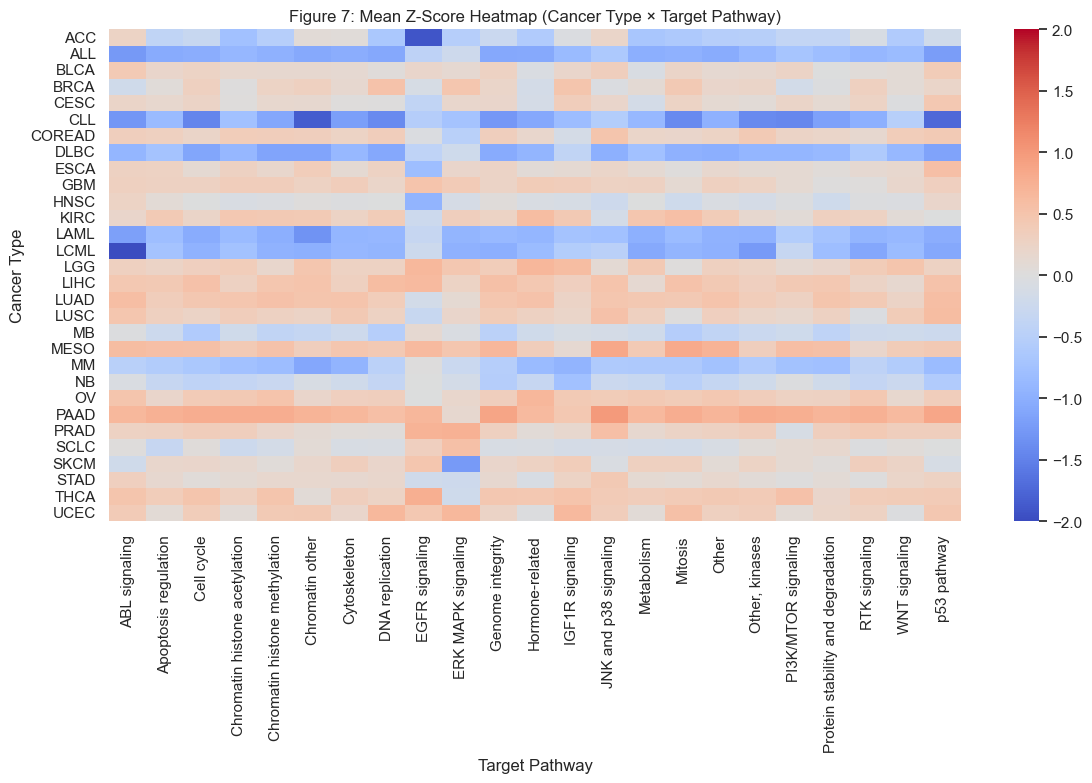

In [123]:
# Heatmap: Mean Z-Score (Cancer Type × Target Pathway)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot_z,
    cmap='coolwarm',
    center=0,
    vmin=-2, vmax=2,
    annot=False
)
plt.title('Figure 7: Mean Z-Score Heatmap (Cancer Type × Target Pathway)')
plt.xlabel('Target Pathway')
plt.ylabel('Cancer Type')
plt.tight_layout()
plt.savefig("figures/Figure7_ZScore_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 7. Mean Z‑Score heatmap (cancer type × target pathway).**  

Heatmap showing mean Z‑Scores across cancer types (Y‑axis) and target pathways (X‑axis). Colors range from blue (−2.0, stronger‑than‑average sensitivity) through orange/light red (moderate sensitivity) to deep red (+2.0, weaker‑than‑average sensitivity).


### Interpretation

Analysis of the cancer type × target pathway heatmap revealed distinct biological response patterns across cancers in Figure 7.

Hematological malignancies, including ALL, LAML, DLBC, and MM, demonstrated broad sensitivity to drugs targeting DNA replication, mitosis, and apoptosis pathways, reflected by predominantly negative Z-scores.

Melanoma (SKCM) exhibited selective sensitivity to ERK/MAPK pathway inhibitors, whereas pancreatic adenocarcinoma (PAAD) and liver hepatocellular carcinoma (LIHC) showed relative resistance across multiple pathways, appearing mainly in regions with positive Z-scores.

Chromatin-related pathways displayed mixed response patterns, with some cancer types showing sensitivity while others appeared resistant.

## 8.6 Overall Interpretation

The results demonstrate that molecular and biological characteristics substantially influence drug response. MSI-H tumors and suspension-growing cell lines generally exhibited greater sensitivity to treatment, while several solid tumors remained comparatively resistant. In addition, drugs targeting mitosis, cell cycle regulation, apoptosis, and DNA replication showed the strongest overall activity across the dataset.

Together, these findings highlight the importance of integrating molecular features, cellular characteristics, and pathway information when evaluating anticancer therapies and support the principles of precision oncology (Iorio et al., 2016).

# 9. Key Biological Insights

Several important biological insights emerged from this analysis.

Hematological malignancies, including ALL, CLL, DLBC, LAML, LCML, and MM, consistently demonstrated greater drug sensitivity than most solid tumors. These cancer types exhibited lower median LN_IC50 values across a broad range of therapies, suggesting increased vulnerability to anticancer treatment.

In contrast, several solid tumors, particularly pancreatic adenocarcinoma (PAAD), ovarian cancer (OV), prostate adenocarcinoma (PRAD), mesothelioma (MESO), and liver hepatocellular carcinoma (LIHC), showed greater resistance to treatment. These findings are consistent with the clinical challenges associated with treating many solid tumors.

Several drugs, including Dactinomycin, Docetaxel, Daporinad, SN-38, Romidepsin, Bortezomib, Luminespib, Sepantronium bromide, and Venetoclax, demonstrated broad activity across multiple cancer types, indicating potential utility across diverse cancer settings.

Drug response was highly heterogeneous across cancer types. Drugs such as Dasatinib, Nilotinib, Gemcitabine, AZD5991, Bosutinib, and Cytarabine displayed substantial variation in sensitivity between cancers, highlighting the importance of cancer-specific treatment strategies.

Genomic and molecular factors also influenced drug response. Cell lines with copy number alterations (CNA) generally showed greater sensitivity than those without CNA. Gene expression status was associated with differences in LN_IC50 and AUC values, while methylation status showed a comparatively smaller overall effect.

Microsatellite instability status influenced treatment response, with MSI-H cell lines exhibiting significantly greater sensitivity than MSS/MSI-L cell lines (Mann–Whitney U test, p < 0.001). Growth properties also affected drug response, with suspension-growing cell lines displaying greater sensitivity than adherent cell lines.

Pathway-level analysis revealed that drugs targeting mitosis, protein stability and degradation, cell cycle regulation, apoptosis, and DNA replication were among the most effective classes across the dataset. These pathways represent important therapeutic vulnerabilities in cancer cells.

Collectively, these findings demonstrate that cancer type, molecular characteristics, growth properties, and drug target pathways all contribute to variation in drug sensitivity and support the principles of precision oncology.


# 10. Limitations

Several limitations should be considered when interpreting these findings.

First, the CNA, Gene Expression, and Methylation variables indicate the availability of molecular data rather than quantitative molecular measurements. Consequently, the analysis cannot directly assess the magnitude of genomic, transcriptomic, or epigenomic alterations.

Second, the dataset is derived from cancer cell line experiments performed under controlled laboratory conditions. Drug responses observed in vitro may not fully reflect treatment outcomes in patients due to differences in tumor microenvironment, immune interactions, and drug pharmacokinetics.

Third, some cancer types are represented by relatively small numbers of cell lines, which may reduce the reliability of sensitivity estimates for those groups.

Fouth, the analysis was primarily descriptive and based on summary statistics. While significant associations were identified, causal relationships between molecular features and drug response cannot be established without further experimental validation.

Finally, observed associations may be influenced by confounding factors such as cancer-type composition, growth characteristics, and underlying molecular heterogeneity that were not fully accounted for in this analysis.


Despite these limitations, the dataset provides valuable insights into patterns of drug sensitivity across a diverse range of cancer types and molecular contexts.


# 11. Conclusion

This study explored drug sensitivity patterns across cancer cell lines using the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. Analysis of LN_IC50, AUC, and Z-score measurements revealed substantial heterogeneity in treatment response across cancer types, drugs, and molecular characteristics.

Hematological malignancies consistently displayed greater sensitivity to treatment, whereas several solid tumors exhibited increased resistance. While some drugs demonstrated broad activity across multiple cancer types, others showed highly selective responses, highlighting the importance of cancer-specific therapeutic strategies.

Molecular and biological factors—including copy number alterations, gene expression status, microsatellite instability, growth properties, and target pathways—were associated with differences in drug response. These findings demonstrate that therapeutic effectiveness is influenced by both cancer type and molecular context.

Overall, this analysis supports the principles of precision oncology and illustrates how integrating pharmacological and molecular data can help identify therapeutic vulnerabilities and guide more effective treatment strategies.


# 12. References

1. HackBio Internship. Public Datasets Repository: GDSC Dataset. GitHub Repository. Available at: https://github.com/HackBio-Internship/public_datasets

2. Yang W, Soares J, Greninger P, et al. (2013). Genomics of Drug Sensitivity in Cancer (GDSC): a resource for therapeutic biomarker discovery in cancer cells. Nucleic Acids Research, 41(Database issue), D955–D961.

3. Genomics of Drug Sensitivity in Cancer (GDSC). Wellcome Sanger Institute. Available at: https://www.cancerrxgene.org/

4. Iorio F, Knijnenburg TA, Vis DJ, et al. (2016). A landscape of pharmacogenomic interactions in cancer. Cell, 166(3), 740–754.


5. National Cancer Institute. TCGA Study Abbreviations. Available at:
https://gdc.cancer.gov/resources-tcga-users/tcga-code-tables/tcga-study-abbreviations
